# Estimación de ingresos anuales de viviendas turísticas en Madrid

Modelo de regresión sobre datos de Inside Airbnb. Análisis exploratorio,
preprocesado, feature engineering y modelado.

El dataset de partida se construye en `dataset_completo.ipynb`.

#### 0. Importamos las librerías necesarias

In [142]:
import ast
import math
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

sys.path.append("../src")
from utils.utils import data_report

pd.options.mode.copy_on_write = True
pd.set_option("display.float_format", "{:.2f}".format)

#### 1. Cargamos los datos

Partimos del dataset construido en `dataset_completo.ipynb`, que unifica los
tres snapshots de 2025 de Inside Airbnb y conserva la versión más reciente de
cada anuncio.

In [2]:
df = pd.read_csv("../data/processed/df_alquileres_original.csv", index_col= "id")

In [3]:
# Miramos los revenue más altos junto al precio y la ocupación que los generan,
# para ver si son valores plausibles o errores del dato de origen

df.nlargest(10, "estimated_revenue_l365d")[["price", "estimated_occupancy_l365d", "estimated_revenue_l365d"]]

,price,estimated_occupancy_l365d,estimated_revenue_l365d
id,,,
5361601,"$25,654.00",78,2001012.00
1060276271097283207,"$9,059.00",84,760956.00
18816591,"$17,159.00",42,720678.00
917927860206046966,"$9,999.00",72,719928.00
33392539,"$3,270.00",162,529740.00
843279194953795764,"$6,613.00",80,529040.00
52716448,"$4,950.00",96,475200.00
918001311360817804,"$9,999.00",42,419958.00
917943830087375379,"$9,999.00",42,419958.00


Los diez revenue más altos confirman la fórmula: el target es el producto de
`price` por `estimated_occupancy_l365d`. Con 1.292 € por noche y 228 noches
ocupadas, Inside Airbnb estima 294.576 € de ingresos.

Varios de esos anuncios tienen precios de 9.999 € o más por noche. En Madrid
existen alojamientos de gama alta, pero precios redondos tan repetidos apuntan
también a calendarios bloqueados con un precio disuasorio.

Queda pendiente contrastarlo con la disponibilidad anual y el anfitrión de cada
anuncio. Conviene tenerlo presente porque el revenue combina el precio actual
con la ocupación del año anterior.

#### 1.1 Exploración de los datos

Primera vista del dataset: dimensiones, tipos de dato, nulos y estadísticos
básicos de las variables numéricas.

In [4]:
df.shape

(31231, 78)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31231 entries, 1342618660420928296 to 53428247
Data columns (total 78 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   listing_url                                   31231 non-null  object 
 1   scrape_id                                     31231 non-null  int64  
 2   last_scraped                                  31231 non-null  object 
 3   source                                        31231 non-null  object 
 4   name                                          31231 non-null  object 
 5   description                                   30192 non-null  object 
 6   neighborhood_overview                         12677 non-null  object 
 7   picture_url                                   31229 non-null  object 
 8   host_id                                       31231 non-null  int64  
 9   host_url                                     

In [6]:
df.describe()

,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,31231.00,31231.00,31133.00,31133.00,31231.00,31231.00,31231.00,24062.00,28286.00,24074.00,...,24879.00,24879.00,24880.00,24877.00,24876.00,31231.00,31231.00,31231.00,31231.00,24880.00
mean,20250825389691.57,281901178.96,56.17,68.26,40.42,-3.69,3.12,1.30,1.43,1.94,...,4.66,4.72,4.73,4.73,4.53,38.99,33.02,5.87,0.08,1.81
std,190504072.51,221961558.18,148.74,198.94,0.02,0.03,1.90,0.70,0.98,1.48,...,0.49,0.47,0.49,0.40,0.54,87.11,84.58,24.38,1.08,2.06
min,20250305023340.00,7952.00,1.00,1.00,40.33,-3.88,1.00,0.00,0.00,0.00,...,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.01
25%,20250914152907.00,60113626.00,1.00,2.00,40.41,-3.71,2.00,1.00,1.00,1.00,...,4.56,4.67,4.70,4.64,4.42,1.00,0.00,0.00,0.00,0.37
50%,20250914152907.00,255229153.00,4.00,6.00,40.42,-3.70,2.00,1.00,1.00,2.00,...,4.79,4.85,4.88,4.86,4.66,4.00,1.00,0.00,0.00,1.15
75%,20250914152907.00,477229015.00,28.00,35.00,40.43,-3.68,4.00,1.50,2.00,2.00,...,4.94,4.98,5.00,4.98,4.83,22.00,13.00,2.00,0.00,2.66
max,20250914152907.00,718454859.00,3311.00,8723.00,40.58,-3.55,16.00,19.00,25.00,40.00,...,5.00,5.00,5.00,5.00,5.00,407.00,407.00,212.00,29.00,82.94


In [7]:
df.columns

Index(['listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar

In [8]:
pd.set_option("display.max_columns", None)
df.head(3)

,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1342618660420928296,https://www.airbnb.com/rooms/1342618660420928296,20250305023340,2025-03-05,city scrape,Amplio Apartamento temporal con Balcón,Discover your ideal home in the heart of Calle...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,450144376,https://www.airbnb.com/users/show/450144376,Fernando,2022-03-18,NaN,NaN,within an hour,100%,100%,f,https://a0.muscache.com/im/pictures/user/fa62b...,https://a0.muscache.com/im/pictures/user/fa62b...,Las Delicias,83.00,83.00,"['email', 'phone']",t,t,NaN,Vallehermoso,Chamberí,40.44,-3.70,Entire rental unit,Entire home/apt,5,1.50,1.5 baths,2.00,3.00,"[""Air conditioning"", ""Paid parking off premise...",$468.00,1,1125,1.00,30.00,75.00,1125.00,22.90,332.60,NaN,t,0,0,0,274,2025-03-05,0,0,0,211,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,77,77,0,0,NaN
21246678,https://www.airbnb.com/rooms/21246678,20250305023340,2025-03-05,city scrape,"Loft a 5’Plaza de Toros ""Las Ventas"" 3rooms 2bath",Great design LOFT 5 minutes from Plaza de Toro...,"The neighborhood is very quiet, 5 minutes from...",https://a0.muscache.com/pictures/a1f24440-6510...,62787624,https://www.airbnb.com/users/show/62787624,Virginia,2016-03-13,"Madrid, Spain","Divertida, tolerante, adoro viajar, conocer ge...",within an hour,100%,95%,f,https://a0.muscache.com/im/pictures/user/468d1...,https://a0.muscache.com/im/pictures/user/468d1...,NaN,2.00,2.00,"['email', 'phone']",t,t,"Madrid, Comunidad de Madrid, Spain",Ventas,Ciudad Lineal,40.43,-3.66,Entire loft,Entire home/apt,6,2.00,2 baths,3.00,3.00,"[""Smoke alarm"", ""Portable fans"", ""Babysitter r...",$209.00,2,730,2.00,2.00,730.00,730.00,2.00,730.00,NaN,t,20,41,64,95,2025-03-05,188,26,2,95,25,156,32604.00,2017-10-15,2025-02-16,4.67,4.70,4.54,4.90,4.86,4.64,4.55,NaN,f,1,1,0,0,2.09
1279145791694933502,https://www.airbnb.com/rooms/1279145791694933502,20250305023340,2025-03-05,city scrape,Habitación Usera,Enjoy the simplicity of this quiet and central...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,659737445,https://www.airbnb.com/users/show/659737445,Camila,2024-10-30,"Madrid, Spain",Holaaa que tal soy Camila y con mi compañera\n...,a few days or more,30%,56%,f,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,NaN,1.00,1.00,"['email', 'phone']",t,t,NaN,Pradolongo,Usera,40.38,-3.71,Private room in rental unit,Private room,2,0.50,Shared half-bath,1.00,2.00,"[""Lock on bedroom door"", ""Kitchen"", ""TV"", ""Air...",$40.00,1,365,1.00,1.00,365.00,

De las 78 columnas, buena parte no sirven como variable predictora.

Cinco son URLs o identificadores sin valor predictivo: `listing_url`,
`picture_url`, `host_url`, `host_thumbnail_url` y `host_picture_url`. Otras
cuatro son texto libre que requeriría procesamiento de lenguaje natural para
aprovecharse: `name`, `description`, `host_about` y `neighborhood_overview`.

Hay bloques con información solapada. De las cuatro variantes de disponibilidad
(`availability_30`, `60`, `90` y `365`), las tres primeras están contenidas en
la última. En cambio las cuatro columnas de `minimum_minimum_nights` a
`maximum_maximum_nights` sí aportan algo propio: recogen los valores extremos de
estancia mínima y máxima del calendario, y reflejan si el anfitrión ajusta las
restricciones por temporada.

Conviene tener en cuenta que esas columnas, igual que las de disponibilidad,
describen los próximos doce meses, mientras que el target mide los 365 días
anteriores.

Por último, un bloque que hay que vigilar: `number_of_reviews` y sus variantes,
`reviews_per_month`, `estimated_occupancy_l365d` y `price`. Todas alimentan,
directa o indirectamente, la fórmula con la que Inside Airbnb calcula el target.

#### 2. Elección de target y definición de X e Y

Elegimos `estimated_revenue_l365d` como variable objetivo: resume el ingreso
anual estimado de un anuncio y es la cifra que interesa a quien evalúa la
rentabilidad de un alojamiento.

Como es una variable continua, el problema es de regresión supervisada.

Conviene recordar que no es un ingreso medido, sino estimado por Inside Airbnb
a partir del precio y de la ocupación deducida de las reseñas. Predecirlo
implica, en parte, aprender esa fórmula.

In [9]:
# Las filas sin target no sirven ni para entrenar ni para evaluar

df = df.dropna(subset=["estimated_revenue_l365d"])

# Reparto: y es la columna objetivo, X todo lo demás

y = df["estimated_revenue_l365d"]
X = df.drop(columns="estimated_revenue_l365d")

#### 3. División en train y test

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

#### 4. Análisis del target y su distribución

In [11]:
y_train.describe()

count    19249.00
mean     12167.80
std      20884.60
min          0.00
25%        300.00
50%       5424.00
75%      17595.00
max     760956.00
Name: estimated_revenue_l365d, dtype: float64

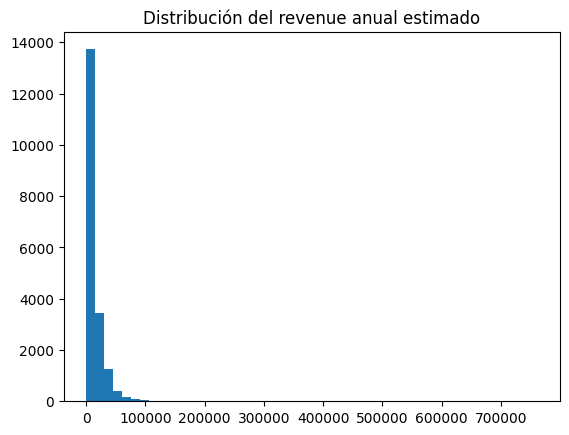

In [12]:
plt.hist(y_train, bins= 50)
plt.title("Distribución del revenue anual estimado")
plt.show()

In [13]:
print((y_train == 0).sum())

4645


In [14]:
y_train.value_counts(bins=[0, 1, 100, 1000, 5000, 20000, 100000, 800000]).sort_index()

(-0.001, 1.0]           4645
(1.0, 100.0]               5
(100.0, 1000.0]         1200
(1000.0, 5000.0]        3527
(5000.0, 20000.0]       5698
(20000.0, 100000.0]     4075
(100000.0, 800000.0]      99
Name: count, dtype: int64

El target tiene una cola muy larga: la mediana está en 5.424 € y el máximo en
760.956 €. Además hay 4.645 anuncios con revenue exactamente 0 (un 24% del
train) y casi nada entre 0 y 100 €, lo que apunta a que no se trata de
alojamientos de bajo rendimiento sino de anuncios sin actividad reciente.
Habrá que confirmarlo más adelante.

Aplicamos `log1p` al target para que los errores pasen a ser relativos:
equivocarse en 1.000 € sobre un anuncio que factura 2.000 pesa igual que
equivocarse en 100.000 sobre uno que factura 200.000. Sin esa transformación el
entrenamiento se concentraría en unos pocos valores extremos. Usamos `log1p` y
no `log` porque calcula `log(1 + x)` y mapea el cero a cero, no a menos
infinito.

In [15]:
y_train_log = np.log1p(y_train)

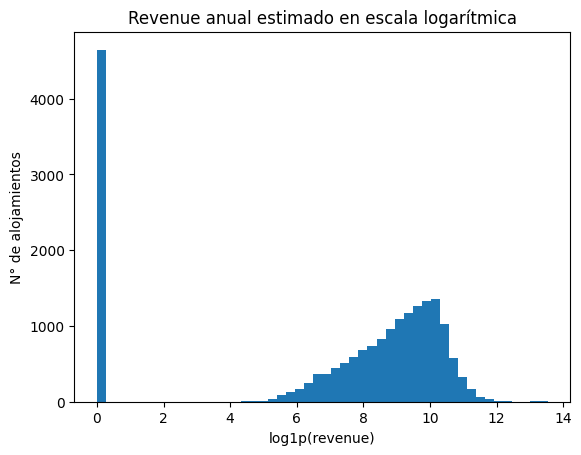

In [16]:
plt.hist(y_train_log, bins=50)
plt.title("Revenue anual estimado en escala logarítmica")
plt.xlabel("log1p(revenue)")
plt.ylabel("N° de alojamientos")
plt.show()

In [17]:
revenue_vs_log = y_train.describe()[["min", "25%", "50%", "75%", "max"]].to_frame("revenue")
revenue_vs_log["log1p"] = np.log1p(revenue_vs_log["revenue"])
revenue_vs_log

,revenue,log1p
min,0.00,0.00
25%,300.00,5.71
50%,5424.00,8.60
75%,17595.00,9.78
max,760956.00,13.54


La transformación funciona: la parte derecha del histograma es ahora una campana
razonablemente simétrica entre 5 y 12, donde antes había una barra aplastada
contra el eje.

Lo que destaca es el hueco. Entre 0,7 y 5 no hay ningún alojamiento, así que los
ceros no son la cola baja de la distribución sino un grupo aparte. La tabla de
abajo del histograma muestra la correspondencia entre euros y escala logarítmica en los
percentiles del target.

#### 5. Comprensión de variables

Revisamos qué tipo de dato tiene cada columna para separar numéricas de
categóricas, y hacemos una primera eliminación de las que no aportan al modelo:
URLs, identificadores y campos de texto libre.

In [18]:
# Cuántas columnas hay de cada tipo

X_train.dtypes.value_counts()

object     36
float64    22
int64      19
Name: count, dtype: int64

In [19]:
# Nulos y cardinalidad de las 77 columnas

data_report(X_train)

COL_N,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
DATA_TYPE,object,int64,object,object,object,object,object,object,int64,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,object,object,object,object,object,object,float64,float64,object,object,int64,float64,object,float64,float64,object,object,int64,int64,float64,float64,float64,float64,float64,float64,float64,object,int64,int64,int64,int64,object,int64,int64,int64,int64,int64,int64,object,object,float64,float64,float64,float64,float64,float64,float64,object,object,int64,int64,int64,int64,float64
MISSINGS (%),0.00,0.00,0.00,0.00,0.00,2.91,59.89,0.00,0.00,0.00,0.38,0.39,33.77,50.05,6.47,6.47,4.01,3.04,0.39,0.39,73.33,0.39,0.39,0.39,0.39,0.39,59.89,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.12,0.14,0.20,0.07,0.00,0.00,0.00,0.00,0.04,0.04,0.04,0.04,0.00,0.00,100.00,0.66,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,16.93,16.93,16.93,16.93,16.94,16.94,16.93,16.93,16.93,62.87,0.00,0.00,0.00,0.00,0.00,16.93
UNIQUE_VALUES,19249,3,14,1,17926,15303,5752,18993,7836,7836,3236,3780,314,3234,4,93,101,2,7391,7391,147,173,199,7,2,2,26,128,21,13529,13138,59,4,16,18,35,14,23,16834,712,77,172,75,95,162,160,495,1002,0,1,31,61,91,366,14,601,164,28,303,157,94,3203,1088,169,162,162,150,150,154,174,5338,2,113,108,44,12,981
CARDIN (%),100.00,0.02,0.07,0.01,93.13,79.50,29.88,98.67,40.71,40.71,16.81,19.64,1.63,16.80,0.02,0.48,0.52,0.01,38.40,38.40,0.76,0.90,1.03,0.04,0.01,0.01,0.14,0.66,0.11,70.28,68.25,0.31,0.02,0.08,0.09,0.18,0.07,0.12,87.45,3.70,0.40,0.89,0.39,0.49,0.84,0.83,2.57,5.21,0.00,0.01,0.16,0.32,0.47,1.90,0.07,3.12,0.85,0.15,1.57,0.82,0.49,16.64,5.65,0.88,0.84,0.84,0.78,0.78,0.80,0.90,27.73,0.01,0.59,0.56,0.23,0.06,5.10


In [20]:
# Las tres columnas de barrio, queremos saber si aportan lo mismo

X_train[["neighbourhood", "neighbourhood_cleansed", "neighbourhood_group_cleansed"]].nunique()

neighbourhood                    26
neighbourhood_cleansed          128
neighbourhood_group_cleansed     21
dtype: int64

In [21]:
# neighbourhood es texto escrito por el anfitrión, sin normalizar

X_train["neighbourhood"].value_counts().head(10)

neighbourhood
Madrid, Comunidad de Madrid, Spain            6947
Madrid, Community of Madrid, Spain             540
Madrid, Spain                                  185
Madrid Center, Madrid, Spain                     8
Chueca, Madrid, Spain                            5
Madrid, Co, Spain                                5
MADRID, Spain                                    5
Madrid , Madrid, Spain                           4
Madrid, Comunidad de Madrid, España, Spain       2
Madrid, SPAIN  Madrid Madrid, Spain              2
Name: count, dtype: int64

In [22]:
# Los 21 distritos oficiales de Madrid

X_train["neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Centro                   8158
Tetuán                   1313
Salamanca                1279
Chamberí                 1162
Arganzuela                933
Carabanchel               716
Retiro                    714
Ciudad Lineal             664
Chamartín                 652
Puente de Vallecas        608
Moncloa - Aravaca         500
Latina                    491
Hortaleza                 428
Usera                     416
San Blas - Canillejas     377
Fuencarral - El Pardo     251
Villaverde                176
Moratalaz                 127
Barajas                   116
Villa de Vallecas          89
Vicálvaro                  79
Name: count, dtype: int64

In [23]:
# Dónde vive el anfitrión: texto libre, pero dominado por Madrid

X_train["host_location"].value_counts().head(10)

host_location
Madrid, Spain              11172
Barcelona, Spain             484
Spain                        117
London, United Kingdom        56
Las Rozas, Spain              27
Málaga, Spain                 23
Buenos Aires, Argentina       20
Majadahonda, Spain            20
Mexico City, Mexico           19
Paris, France                 17
Name: count, dtype: int64

In [24]:
# Barrio del anfitrión, no del alojamiento

X_train["host_neighbourhood"].value_counts().head(10)

host_neighbourhood
Sol             672
Malasaña        413
Embajadores     413
Cortes          365
La Latina       334
Justicia        295
Palacio         229
Las Delicias    108
Recoletos       106
Castillejos      97
Name: count, dtype: int64

In [25]:
# Descripción del barrio: texto largo y repetido entre anuncios de una misma gestora

X_train["neighborhood_overview"].value_counts().head()

neighborhood_overview
The area between Puerta del Sol and Gran Vía and its surroundings is undoubtly the axis around which Madrid's tourist, cultural and recreational life develops. This area is the starting point of any tourist route through the city, and in its absence, is a must for any visitor who wants to feel the heartbeat of Madrid. The new Gran Vía is free of cars and pollution and is more pedestrian friendly.<br />Sol-Gran Vía is one of the main commercial areas of Madrid. Shopping in its streets and window shopping is an experience that no visitor should miss. A day of shopping here is like strolling through a large open-air shopping mall.                                                                                                                                                                                                                                                                                                                                                       

In [26]:
# Licencia turística: códigos, exenciones y texto libre mezclados

X_train["license"].value_counts().head(10)

license
Exempt                                                   487
En proceso                                               286
ESABCD123456789123456789123456789123456-HH-7891234567     34
350202309690                                              26
VT REGISTRADA                                             24
VT                                                        21
EXENTO - Alquiler de Temporada según la LAU               19
ESFCNT00002811800025303900000000000000000000000000001     19
ESFCNT0000000000000000000000000000000000000000VT10390     18
ESFCTU00002809100037815800000000000000000000000000002     17
Name: count, dtype: int64

In [27]:
# Cuántos anuncios tienen algo escrito en license

X_train["license"].notna().sum()

np.int64(7148)

In [28]:
# Versión textual de bathrooms: distingue baños compartidos y tiene menos nulos que la numérica

X_train["bathrooms_text"].value_counts().head(15)

bathrooms_text
1 bath              10121
2 baths              2651
1 shared bath        2286
1 private bath       1390
1.5 baths             531
2 shared baths        485
3 baths               373
1.5 shared baths      261
Shared half-bath      175
2.5 baths             155
3 shared baths        154
4 baths                87
0 baths                80
Half-bath              77
0 shared baths         67
Name: count, dtype: int64

In [29]:
# Lista de servicios del alojamiento en texto: distinta en cada fila

X_train["amenities"].head(3)

id
50630756               ["Free street parking", "Hair dryer", "Air con...
734651832390332724     ["Dishes and silverware", "Hot water", "Drying...
1384749260794620824    ["Freezer", "Long term stays allowed", "Hot wa...
Name: amenities, dtype: object

In [30]:
X_train["amenities"].apply(lambda x: len(ast.literal_eval(x)))

id
50630756               11
734651832390332724     18
1384749260794620824    11
1371854256044615873    26
52064011               43
                       ..
1051464381946088875    27
1023234335190631644    45
1299150232151719103     7
1204269959031280563    61
993987964856337671     18
Name: amenities, Length: 19249, dtype: int64

In [31]:
# ¿Las filas sin bathrooms numérico tienen el dato en el texto?

X_train.loc[X_train["bathrooms"].isna(), "bathrooms_text"].value_counts(dropna=False).head(10)

bathrooms_text
NaN    24
Name: count, dtype: int64

In [32]:
X_train["bathrooms"].isna().sum()

np.int64(24)

Con esto ya se puede decidir qué columnas sobran.

Salen las cinco URLs y `scrape_id`, que son identificadores sin valor
predictivo, y los campos de texto libre: `name`, `host_name`, `description`,
`host_about` y `neighborhood_overview`. `calendar_updated` está vacía al 100%.

`neighbourhood` se elimina porque es texto sin normalizar y con un 60% de nulos,
mientras que `neighbourhood_cleansed` y `neighbourhood_group_cleansed` cubren lo
mismo completas y ordenadas en 128 barrios y 21 distritos.
`host_neighbourhood` se va por el 73% de nulos y por referirse al anfitrión, no
al alojamiento.

Se conservan cuatro columnas que habrá que transformar más adelante.
`host_location` pasará a indicar si el anfitrión reside en Madrid, y `license`
si el anuncio declara licencia: solo 7.148 de 19.249 anuncios tienen algo
escrito en ese campo, y lo que hay mezcla códigos con exenciones y trámites en
curso, así que la versión binaria recoge casi toda la señal sin necesidad de
interpretar el texto.

`bathrooms_text` se mantiene aunque el número de baños ya esté en `bathrooms`,
porque distingue los compartidos de los privados, que son unos 3.400 anuncios.
De `amenities` se extraerá el número de servicios de cada alojamiento.

In [33]:
# Primera eliminación de variables que no aportan al modelo
cols_drop = [
    "listing_url",
    "scrape_id",
    "picture_url",
    "host_url",
    "host_thumbnail_url",
    "host_picture_url",
    "name",
    "host_name",
    "description",
    "host_about",
    "neighborhood_overview",
    "neighbourhood",
    "host_neighbourhood",
    "calendar_updated",
]

X_train = X_train.drop(columns=cols_drop, errors="ignore")
X_test = X_test.drop(columns=cols_drop, errors="ignore")

X_train.shape

(19249, 63)

In [34]:
X_test.shape

(4813, 63)

#### 5.1 Análisis univariante

Antes de separar numéricas de categóricas hay que corregir tres columnas que
llegan como texto aunque sean numéricas: `price` trae el símbolo de moneda y
separador de miles, y `host_response_rate` y `host_acceptance_rate` vienen con
el símbolo de porcentaje.

In [35]:
for datos in [X_train, X_test]:
    
    datos["price"] = (
        datos["price"]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float))
    
    for col in ["host_response_rate", "host_acceptance_rate"]:
        datos[col] = datos[col].str.replace("%", "", regex=False).astype(float)

In [36]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

In [37]:
num_cols

['host_id',
 'host_response_rate',
 'host_acceptance_rate',
 'host_listings_count',
 'host_total_listings_count',
 'latitude',
 'longitude',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_r

In [38]:
cat_cols

['last_scraped',
 'source',
 'host_since',
 'host_location',
 'host_response_time',
 'host_is_superhost',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'property_type',
 'room_type',
 'bathrooms_text',
 'amenities',
 'has_availability',
 'calendar_last_scraped',
 'first_review',
 'last_review',
 'license',
 'instant_bookable']

In [39]:
print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 42
Categóricas: 21


In [40]:
X_train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
host_id,19249.00,300707711.44,225513638.97,7952.00,68676249.00,299447254.00,495402442.00,718454859.00
host_response_rate,18004.00,90.67,21.94,0.00,95.00,100.00,100.00,100.00
host_acceptance_rate,18478.00,84.11,27.20,0.00,83.00,98.00,100.00,100.00
host_listings_count,19174.00,62.05,155.73,1.00,2.00,6.00,34.00,3311.00
host_total_listings_count,19174.00,75.48,204.93,1.00,2.00,8.00,45.00,8554.00
latitude,19249.00,40.42,0.02,40.33,40.41,40.42,40.43,40.58
longitude,19249.00,-3.69,0.03,-3.88,-3.71,-3.70,-3.68,-3.55
accommodates,19249.00,3.23,1.93,1.00,2.00,3.00,4.00,16.00
bathrooms,19225.00,1.30,0.69,0.00,1.00,1.00,1.50,15.00
bedrooms,19210.00,1.37,0.92,0.00,1.00,1.00,2.00,25.00


In [41]:
(X_train["price"] == 0).sum()

np.int64(1)

In [42]:
y_train[X_train["price"] == 0]

id
1400665104227377821   0.00
Name: estimated_revenue_l365d, dtype: float64

In [43]:
X_train.loc[y_train == 0, ["number_of_reviews", "number_of_reviews_ltm", "availability_365"]].describe()

,number_of_reviews,number_of_reviews_ltm,availability_365
count,4645.00,4645.00,4645.00
mean,5.23,0.00,228.46
std,27.66,0.00,118.72
min,0.00,0.00,0.00
25%,0.00,0.00,115.00
50%,0.00,0.00,259.00
75%,1.00,0.00,339.00
max,603.00,0.00,365.00


Los 4.645 anuncios con revenue 0 no tienen ninguna reseña en el último año, sin
excepción, y la mediana de reseñas históricas es 0: en su mayoría son anuncios
publicados que nunca llegaron a funcionar. El calendario está abierto (mediana
de 259 días disponibles), así que no se trata de alojamientos bloqueados.

Los eliminamos. El objetivo es estimar cuánto puede facturar un alojamiento que
se alquila, y estos no aportan información sobre eso: lo único que los
distingue de un anuncio activo es la ausencia de reseñas, que es precisamente
una de las variables que hay que retirar por leakage. Manteniéndolos, el modelo
vería dos grupos con features equivalentes y targets opuestos.

Conviene dejar constancia del alcance que esto define: el modelo aprende solo de
alojamientos con actividad, así que no puede anticipar que un anuncio concreto
no llegue a alquilarse.

In [44]:
# Eliminamos los anuncios sin actividad, manteniendo X e y alineados

mask_train = y_train > 0

X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = y_test > 0

X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Recalculamos el target en escala logarítmica

y_train_log = np.log1p(y_train)

print(X_train.shape, X_test.shape)

(14604, 63) (3623, 63)


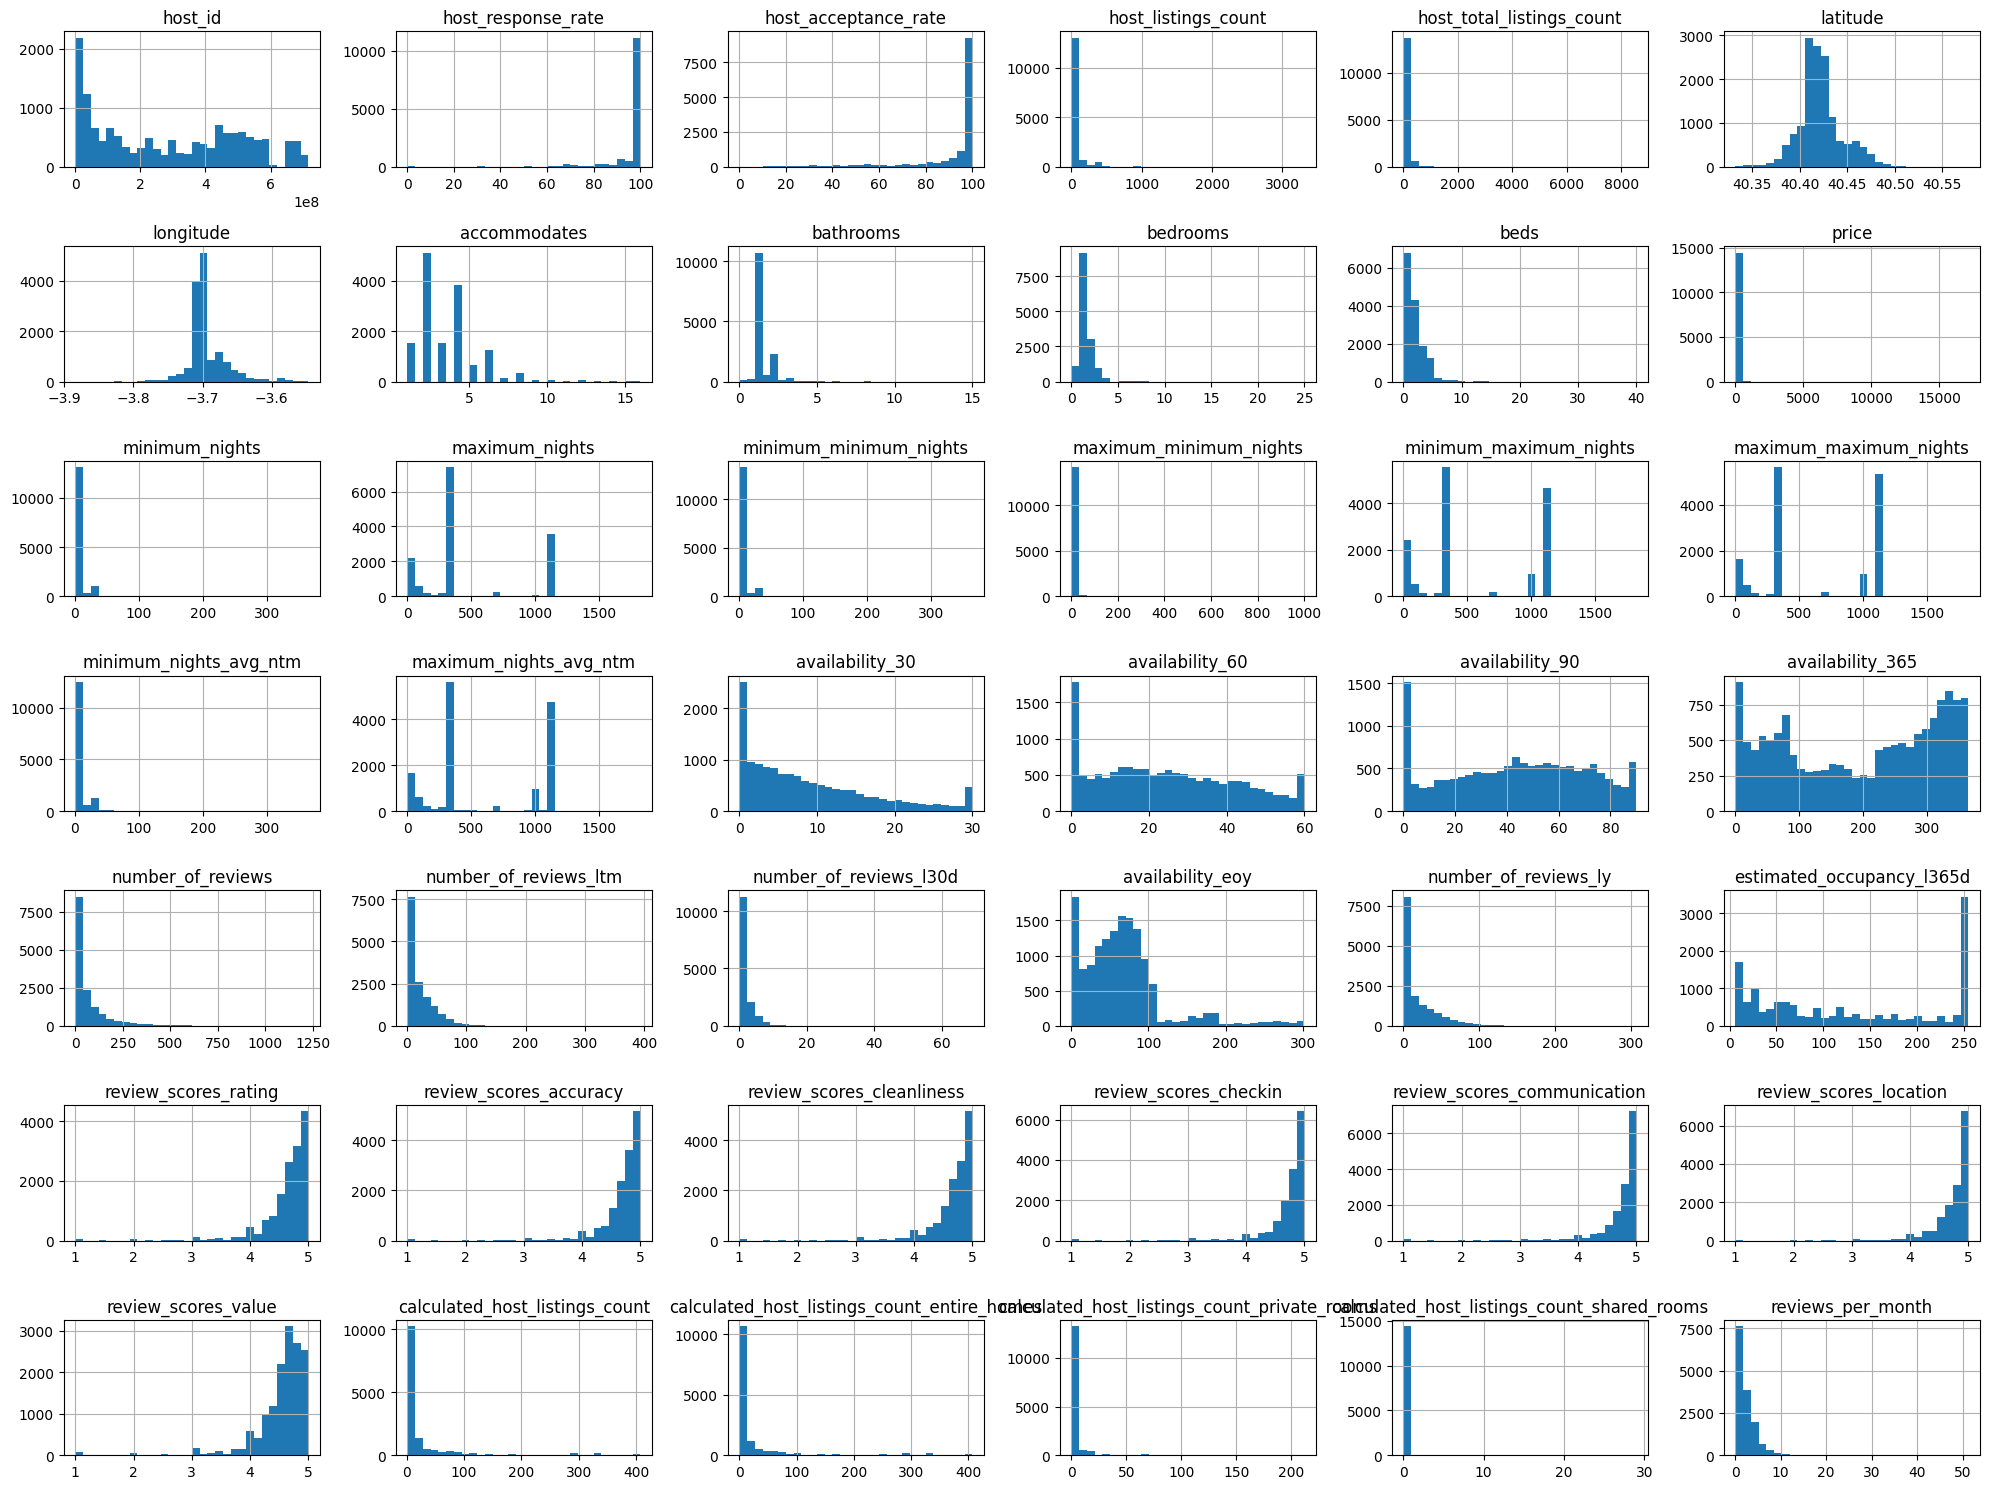

In [45]:
X_train[num_cols].hist(figsize=(20,15), bins=30)
plt.tight_layout()
plt.show()

In [46]:
# availability_30, 60 y 90 están contenidas en availability_365

cols_drop_disponibilidad = ["availability_30", "availability_60", "availability_90"]

X_train = X_train.drop(columns=cols_drop_disponibilidad, errors="ignore")
X_test = X_test.drop(columns=cols_drop_disponibilidad, errors="ignore")

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

X_train.shape

(14604, 60)

Los histogramas confirman la asimetría a la derecha en casi todas las variables:
`price`, `minimum_nights`, los recuentos de anuncios del anfitrión y todo el
bloque de reseñas están concentrados cerca de cero con colas largas. Habrá que
tratar los valores extremos más adelante.

Dos hallazgos concretos. `estimated_occupancy_l365d` acumula un pico en 255, que
es el 70% de 365: el tope de ocupación que aplica Inside Airbnb, visible aquí en
los propios datos. Y las variables de noches máximas muestran dos picos, en 365
y en 1.125, así que no recogen decisiones del anfitrión sino valores por defecto
de la plataforma.

Los `review_scores` se concentran entre 4,5 y 5 con muy poca dispersión, algo
habitual en Airbnb, por lo que difícilmente van a discriminar entre alojamientos.
Lo mismo ocurre con `host_response_rate` y `host_acceptance_rate`, con casi toda
la masa en 100.

Eliminamos `availability_30`, `availability_60` y `availability_90`: las tres
están contenidas en `availability_365`, que además es la única del bloque con una
distribución bien repartida. Queda pendiente decidir sobre `host_id`, que es un
identificador y no puede entrar al modelo, y sobre `availability_eoy`, cuya
ventana temporal depende de la fecha de scraping y no es comparable entre filas.

#### 5.2 Analizamos la correlacion entre las variables numericas y la variable target.


In [47]:
corr_with_target = X_train[num_cols].corrwith(y_train_log).sort_values(ascending=False)
corr_with_target.head(15)

estimated_occupancy_l365d   0.78
number_of_reviews_ltm       0.56
number_of_reviews_ly        0.50
number_of_reviews           0.42
reviews_per_month           0.42
accommodates                0.35
host_acceptance_rate        0.31
number_of_reviews_l30d      0.31
beds                        0.24
bedrooms                    0.24
review_scores_rating        0.23
review_scores_cleanliness   0.23
host_response_rate          0.22
review_scores_accuracy      0.22
review_scores_value         0.21
dtype: float64

In [48]:
corr_with_target["price"]

np.float64(0.21084228309202196)

In [49]:
corr_with_target.tail(10)

minimum_minimum_nights                          0.03
host_listings_count                             0.02
host_total_listings_count                       0.02
latitude                                        0.02
longitude                                      -0.05
availability_365                               -0.08
calculated_host_listings_count_shared_rooms    -0.13
calculated_host_listings_count_private_rooms   -0.13
availability_eoy                               -0.16
host_id                                        -0.19
dtype: float64

Las correlaciones más altas con el revenue log-transformado corresponden todas
al mismo bloque: la ocupación estimada (0,78) y las métricas de reseñas
(`number_of_reviews_ltm` 0,56, `number_of_reviews_ly` 0,50, `number_of_reviews`
y `reviews_per_month` 0,42). No es un hallazgo del análisis: son las variables
con las que Inside Airbnb construye el target.

Por debajo de ese bloque la señal es débil. `accommodates` llega a 0,35, `beds`
y `bedrooms` a 0,24, y los `review_scores` rondan 0,22. `price`, pese a ser
factor directo del target, se queda en 0,21, porque en escala logarítmica el
producto se convierte en suma y la ocupación explica mucha más variación que el
precio.

En la cola aparecen valores cercanos a cero: `latitude` y `longitude` apenas
correlacionan, aunque eso no significa que la ubicación no importe, sino que su
relación con el revenue no es lineal y habrá que capturarla mediante el barrio.
`availability_365` se queda en -0,08, coherente con que mida disponibilidad
futura mientras el target recoge los 365 días anteriores.

Conviene anticipar la consecuencia: al retirar el bloque de la fórmula, el
modelo quedará con predictores débiles y las métricas caerán de forma notable.

In [50]:
# Correlación entre las variables del bloque de la fórmula

formula_vars = [
    "estimated_occupancy_l365d",
    "number_of_reviews_ltm",
    "number_of_reviews_ly",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "number_of_reviews",
]

X_train[formula_vars].corr()

,estimated_occupancy_l365d,number_of_reviews_ltm,number_of_reviews_ly,number_of_reviews_l30d,reviews_per_month,number_of_reviews
estimated_occupancy_l365d,1.00,0.76,0.66,0.43,0.58,0.54
number_of_reviews_ltm,0.76,1.00,0.84,0.66,0.82,0.67
number_of_reviews_ly,0.66,0.84,1.00,0.41,0.63,0.77
number_of_reviews_l30d,0.43,0.66,0.41,1.00,0.76,0.36
reviews_per_month,0.58,0.82,0.63,0.76,1.00,0.51
number_of_reviews,0.54,0.67,0.77,0.36,0.51,1.00


El bloque está fuertemente correlacionado consigo mismo: `number_of_reviews_ltm`
alcanza 0,84 con `number_of_reviews_ly` y 0,82 con `reviews_per_month`. Son
medidas del mismo fenómeno en distintas ventanas temporales, así que introducir
todas juntas aporta poca información nueva y sí multicolinealidad.

La ocupación no correlaciona perfectamente con las reseñas (0,76 con
`number_of_reviews_ltm`) porque el cálculo incluye el tope del 70% y la estancia
mínima, que rompen la proporcionalidad en la parte alta.

#### 5.3 Análisis de las variables categóricas

Revisamos cardinalidad, reparto de categorías y nulos de las 21 columnas de
tipo objeto que quedan en `X_train`.

In [51]:
cardinalidad_cat = pd.DataFrame({
    "columna": cat_cols,
    "unicos": [X_train[col].nunique() for col in cat_cols],
    "nulos_%": [X_train[col].isna().mean() * 100 for col in cat_cols],
}).sort_values("unicos", ascending=False)

cardinalidad_cat

,columna,unicos,nulos_%
14,amenities,13485,0.00
19,license,4525,59.51
2,host_since,3449,0.51
17,first_review,3069,0.00
18,last_review,452,0.00
3,host_location,247,32.40
9,neighbourhood_cleansed,127,0.00
11,property_type,53,0.00
13,bathrooms_text,34,0.08
10,neighbourhood_group_cleansed,21,0.00


In [52]:
X_train["host_verifications"].value_counts(dropna=False)

host_verifications
['email', 'phone']                  11365
['email', 'phone', 'work_email']     1704
['phone']                            1383
NaN                                    74
['phone', 'work_email']                64
['email', 'work_email']                 7
['email']                               5
[]                                      2
Name: count, dtype: int64

Cinco columnas se descartan aquí mismo: `source` y `has_availability` tienen un
único valor, `last_scraped` y `calendar_last_scraped` son metadatos del
scraping, y `host_verifications` guarda por qué vía se verificó el anfitrión
(el 90% son `['email', 'phone']` o esa misma lista con `work_email`), un dato
que el huésped no ve al reservar y que quien use la API tampoco podría
introducir. Lo que sí se muestra en el anuncio es si el anfitrión está
verificado, y eso ya lo recoge `host_identity_verified`.

Las de mayor cardinalidad no son categóricas sino contenedores de los que habrá
que extraer una señal concreta: listas (`amenities`), texto libre (`license`,
`host_location`, `bathrooms_text`) y fechas (`host_since`, `first_review`,
`last_review`).

Llama la atención que `first_review` y `last_review` no tengan ningún nulo,
cuando `reviews_per_month` tenía un 17% antes de eliminar los anuncios sin
actividad. Es consecuencia de la fórmula del target: sin reseñas en el último
año la ocupación estimada es cero, así que esas filas ya salieron del dataset.

In [53]:
# Constantes, metadatos del scraping y una variable que el usuario final no puede conocer

cols_drop_cat = [
    "source",
    "has_availability",
    "last_scraped",
    "calendar_last_scraped",
    "host_verifications",
]

X_train = X_train.drop(columns= cols_drop_cat, errors="ignore")
X_test = X_test.drop(columns= cols_drop_cat, errors="ignore")

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

X_train.shape

(14604, 55)

In [54]:
# Las categóricas con categorías cerradas: se pueden agrupar y comparar directamente.
# El resto de columnas de tipo objeto son contenedores (listas, texto libre, fechas)
# de los que primero hay que extraer una feature, así que se analizan más adelante.

cat_analysis = [
    "room_type",
    "property_type",
    "neighbourhood_group_cleansed",
    "neighbourhood_cleansed",
    "host_response_time",
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "instant_bookable",
]

In [55]:
for col in cat_analysis:
    print("\n", col)
    print(
        y_train_log.groupby(X_train[col], dropna=False)
        .agg(["mean", "count"])
        .sort_values("mean"))


 room_type
                 mean  count
room_type                   
Shared room      7.16    129
Hotel room       7.81     17
Private room     8.16   3917
Entire home/apt  9.34  10541

 property_type
                                    mean  count
property_type                                  
Private room in minsu               6.20      1
Room in serviced apartment          6.20      1
Shared room in bed and breakfast    6.57     33
Shared room in home                 6.93      4
Shared room in rental unit          7.10     26
Shared room in hostel               7.40     36
Shared room in hotel                7.50     27
Private room in tiny home           7.67      7
Camper/RV                           7.76      4
Room in hostel                      7.85     13
Private room                        7.86      9
Private room in bed and breakfast   7.87     96
Private room in villa               7.94      7
Private room in floor               8.01      1
Private room in rental unit   

Dos variables separan con claridad. `room_type` va de 7,16 en habitación
compartida a 9,34 en alojamiento entero, y `neighbourhood_group_cleansed` de
8,07 en Villaverde a 9,31 en Centro y Salamanca, con un orden que coincide con
la geografía real de la ciudad. `host_response_time` muestra un gradiente
limpio de 7,83 a 9,13 que respeta el orden natural de sus categorías, así que
puede codificarse como ordinal en lugar de generar cuatro dummies.

`property_type` es engañosa: sus valores extremos corresponden a categorías con
uno o dos anuncios, y lo único con volumen real son `Entire rental unit` y
`Private room in rental unit`, que ya distingue `room_type`. Las binarias del
anfitrión aportan poco, con diferencias de 0,17 en `host_identity_verified` y
0,20 en `instant_bookable`; solo `host_is_superhost` llega a 0,73. En las tres
la categoría de nulos tiene la media más alta, algo a revisar antes de imputar.

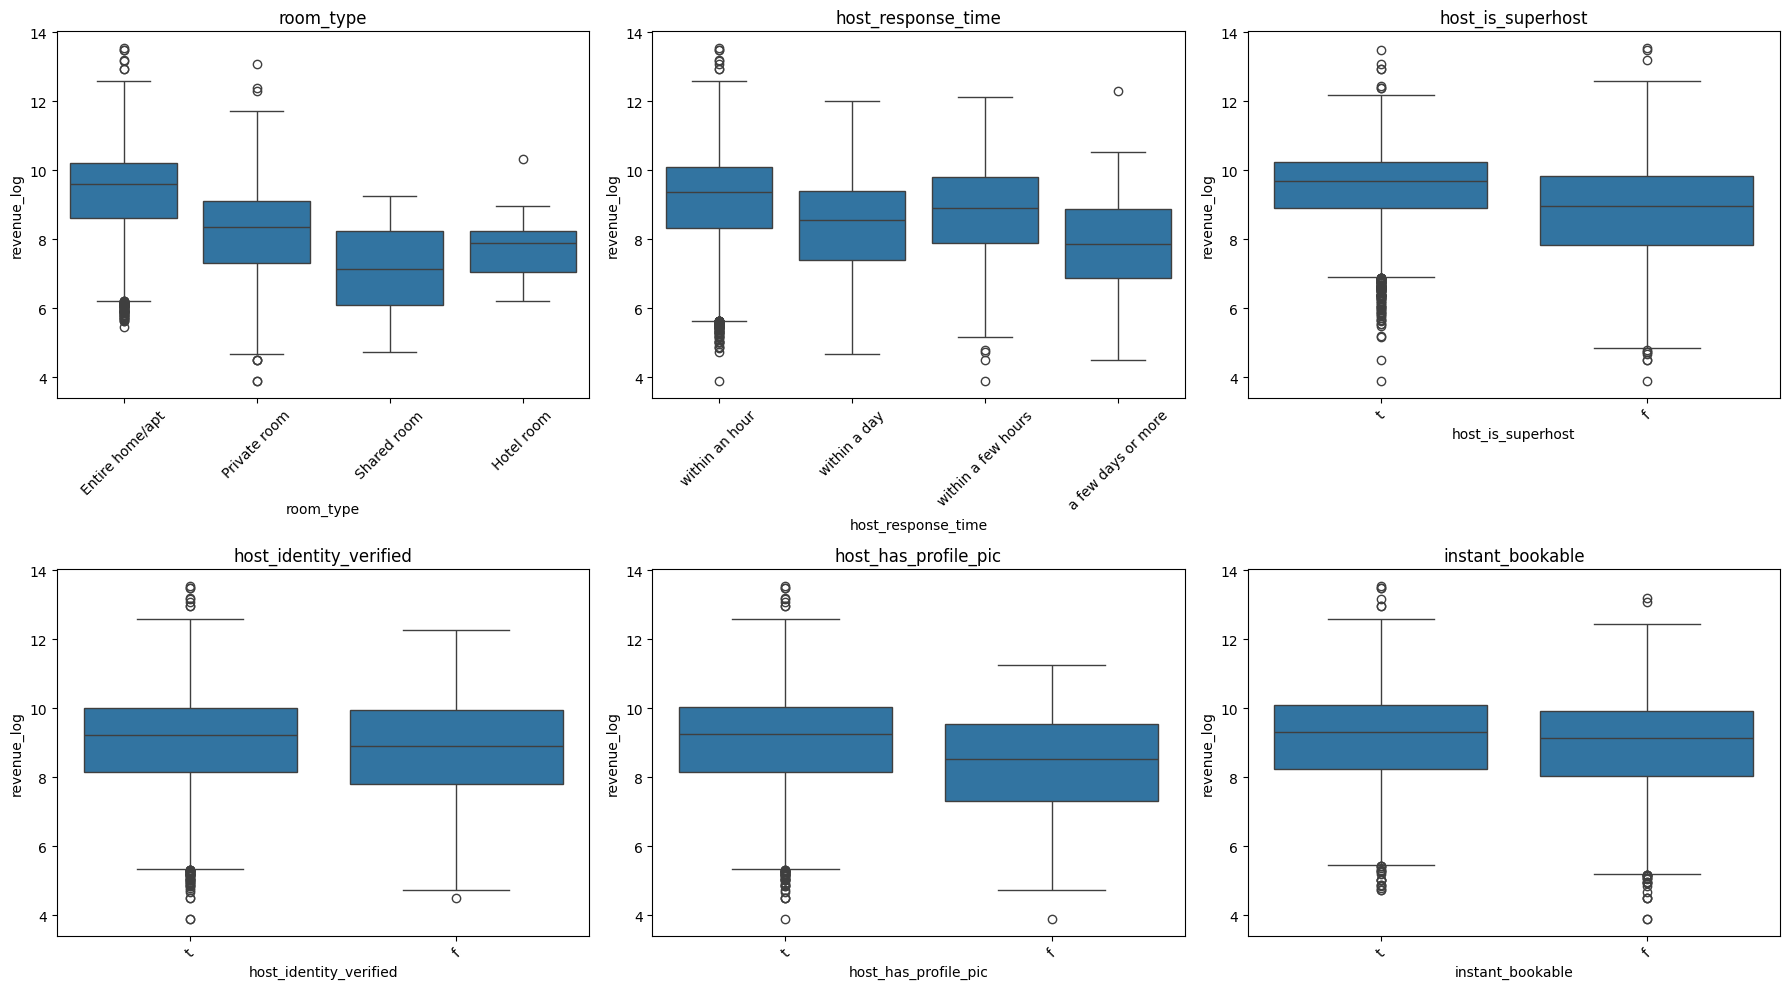

In [56]:
df_plot = X_train.join(y_train_log.rename("revenue_log"))

cat_grid = [c for c in cat_analysis if c not in ["property_type", "neighbourhood_cleansed", "neighbourhood_group_cleansed"]]

n_cols = 3
n_rows = math.ceil(len(cat_grid) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cat_grid):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df_plot, x=col, y="revenue_log", ax=ax)
    ax.tick_params(axis="x", rotation=45)
    ax.set_title(col)

plt.tight_layout()
plt.show()

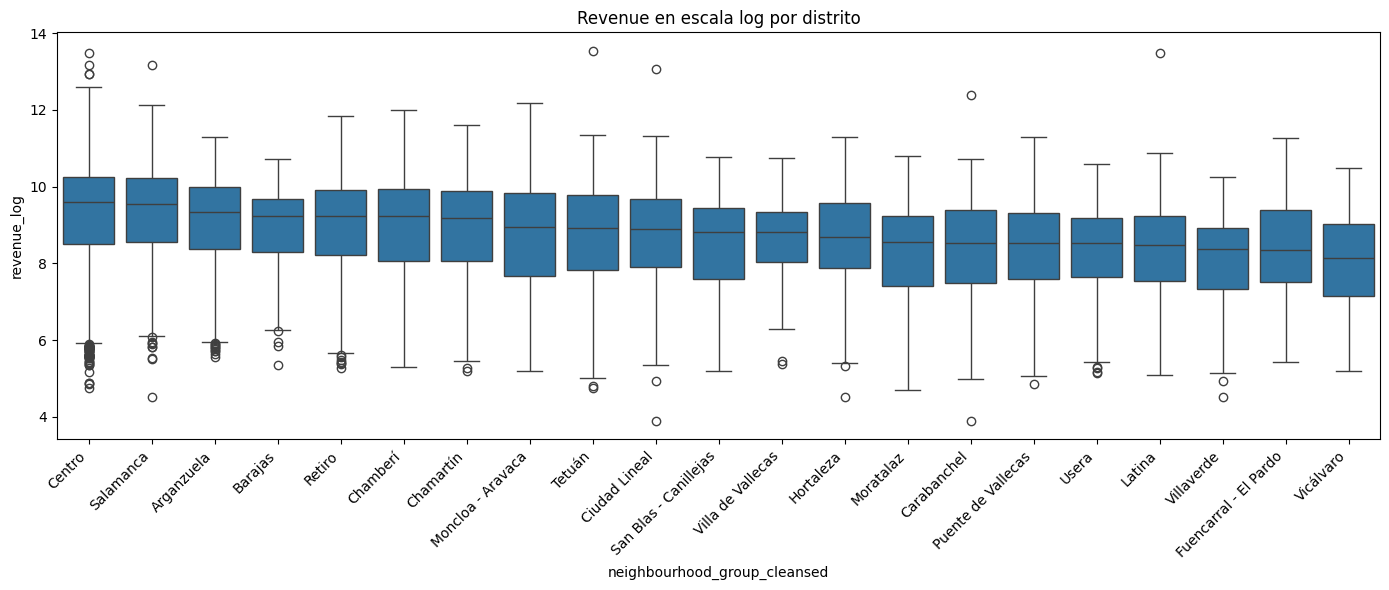

In [57]:
order = (
    df_plot.groupby("neighbourhood_group_cleansed")["revenue_log"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_plot, x="neighbourhood_group_cleansed", y="revenue_log", order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Revenue en escala log por distrito")
plt.tight_layout()
plt.show()

Los boxplots confirman lo que apuntaban las medias y añaden la dispersión.
`room_type` separa con claridad, y `host_is_superhost` y `host_has_profile_pic`
muestran cajas desplazadas entre sus dos valores. En cambio
`host_identity_verified` e `instant_bookable` tienen cajas casi idénticas, así
que aportan poco.

En los distritos la mediana baja de forma gradual, de 9,6 en Centro a 8,1 en
Vicálvaro, sin escalones bruscos. El comportamiento es parecido en todos: cajas
de tamaño similar y recorrido intercuartílico concentrado entre 8 y 10. Lo que
cambia es dónde está centrada cada una, así que el distrito desplaza el nivel
medio pero no separa grupos distintos, y por sí solo no determina el revenue.
Aun así el recorrido no es despreciable, porque en escala logarítmica esa
diferencia de 1,5 equivale a multiplicar por 4,5 en euros.

Los valores atípicos aparecen casi todos por debajo de las cajas, no por
encima. Es efecto de la transformación logarítmica, que comprimió la cola alta
y dejó expuestos los anuncios de facturación mínima: un punto en 4 equivale a
unos 54 € anuales. Habrá que revisarlos en la sección de outliers, porque
apuntan a anuncios con actividad casi nula, cercanos a los ceros que ya se
eliminaron.

In [58]:
barrios = (
    y_train_log.groupby(X_train["neighbourhood_cleansed"])
    .agg(["mean", "count"])
    .sort_values("count")
)

print("Barrios con menos de 30 anuncios:", (barrios["count"] < 30).sum())
print("Anuncios que suman esos barrios:", barrios.loc[barrios["count"] < 30, "count"].sum())

barrios.head(15)

Barrios con menos de 30 anuncios: 43
Anuncios que suman esos barrios: 659


,mean,count
neighbourhood_cleansed,,
El Pardo,6.40,1
Horcajo,8.64,3
Santa Eugenia,9.67,3
Valdemarín,8.68,3
Cuatro Vientos,9.01,4
Fuentelareina,9.59,4
Amposta,7.65,5
Palomas,8.20,6
Pavones,8.68,7


`neighbourhood_cleansed` tiene 127 barrios, pero 43 de ellos reúnen menos de 30
anuncios cada uno y entre todos suman 659, un 4,5% del train. Son barrios de la
periferia con poca actividad turística: El Pardo aparece con un solo anuncio y
varios más con tres o cuatro.

Eso condiciona el tratamiento. Un target encoding directo le asignaría a El
Pardo la media de ese único anuncio, que es ruido y no información del barrio,
así que habrá que aplicar suavizado para que las categorías con pocos registros
se acerquen a la media global. La codificación se resuelve en feature
engineering.

#### 6. Reducción de features

In [59]:
# Días disponibles hasta fin de año: la ventana depende de la fecha de scraping,
# así que no es comparable entre filas de snapshots distintos

X_train = X_train.drop(columns="availability_eoy", errors="ignore")
X_test = X_test.drop(columns="availability_eoy", errors="ignore")

X_train.shape

(14604, 54)

`availability_eoy` cuenta los días disponibles hasta el 31 de diciembre, así que
la ventana que mide depende de la fecha de scraping: diez meses en una fila de
marzo y tres en una de septiembre. A eso se suma que no es una variable que el
usuario final pueda aportar, porque quien evalúa la compra de un piso no sabe
cuántos días quedarán libres hasta fin de año. Se elimina.

In [60]:
X_train[["minimum_nights", "maximum_nights"]].describe()

,minimum_nights,maximum_nights
count,14604.00,14604.00
mean,5.40,493.17
std,14.12,387.04
min,1.00,1.00
25%,1.00,360.00
50%,2.00,365.00
75%,3.00,730.00
max,365.00,1825.00


In [61]:
X_train["maximum_nights"].value_counts().head(10)

maximum_nights
365     6921
1125    3496
30       577
90       361
60       297
730      230
15       177
330      154
180      149
360      143
Name: count, dtype: int64

In [62]:
# Del bloque de noches conservamos solo minimum_nights: el resto son valores
# por defecto de la plataforma o agregados del calendario futuro

nights_drop = [
    "maximum_nights",
    "minimum_minimum_nights",
    "maximum_minimum_nights",
    "minimum_maximum_nights",
    "maximum_maximum_nights",
    "minimum_nights_avg_ntm",
    "maximum_nights_avg_ntm",
]

X_train = X_train.drop(columns=nights_drop, errors="ignore")
X_test = X_test.drop(columns=nights_drop, errors="ignore")

X_train.shape

(14604, 47)

Del bloque de estancia mínima y máxima se conserva solo `minimum_nights`, que
tiene reparto real (mediana de 2 noches) y significado de negocio, porque un
mínimo alto apunta a alquiler de temporada más que turístico. `maximum_nights`
se concentra en los dos valores por defecto de la plataforma, 365 y 1125, que
entre ambos cubren el 71% del train, así que refleja si el anfitrión tocó el
campo y no una característica del alojamiento. Las seis variantes restantes son
agregados del calendario de los próximos doce meses, una ventana distinta a la
que mide el target.

In [63]:
X_train[["host_listings_count", "calculated_host_listings_count"]].describe()

,host_listings_count,calculated_host_listings_count
count,14530.00,14604.00
mean,42.41,31.64
std,106.49,71.78
min,1.00,1.00
25%,2.00,1.00
50%,5.00,4.00
75%,25.00,21.00
max,3311.00,407.00


In [64]:
# Contamos anuncios por anfitrión en el propio dataset y lo comparamos
# con lo que dicen las dos columnas

conteo_real = X_train.groupby("host_id")["price"].transform("size")

comparacion = pd.DataFrame({
    "real_en_dataset": conteo_real,
    "calculated": X_train["calculated_host_listings_count"],
    "perfil": X_train["host_listings_count"],
})

comparacion.nlargest(10, "perfil")

,real_en_dataset,calculated,perfil
id,,,
1222425049429274277,1,5,3311.00
691820894180914021,29,61,957.00
691818641031589320,29,61,957.00
1262780716268389428,29,61,957.00
1380475512509288956,29,61,957.00
691842542508923151,29,61,957.00
948262195368034913,29,61,957.00
735979715877732955,29,61,957.00
944848351913795046,29,61,957.00


In [65]:
# Seis columnas miden el tamaño del anfitrión. Nos quedamos con el conteo en
# Madrid, que es el mercado del modelo y no tiene nulos

host_count_drop = [
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

X_train = X_train.drop(columns=host_count_drop, errors="ignore")
X_test = X_test.drop(columns=host_count_drop, errors="ignore")

X_train.shape

(14604, 42)

Seis columnas miden el tamaño del anfitrión. Dos vienen de su perfil y cuentan
anuncios en todo el mundo, y cuatro las calcula Inside Airbnb sobre el propio
archivo de Madrid. La comparación lo confirma: un anfitrión con 957 anuncios en
el perfil tiene 61 en Madrid, y otro con 3.311 tiene solo 5. Nos quedamos con
`calculated_host_listings_count`, que mide el mercado que interesa, no tiene
nulos y es un dato que el usuario de la API puede aportar. La hipótesis es que
un gestor profesional obtiene más ocupación que un particular con un solo piso,
aunque habrá que confirmarlo, porque su correlación con el target es de solo
0,02.

In [66]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 26
Categóricas: 16


In [67]:
print("Numéricas")
num_cols

Numéricas


['host_id',
 'host_response_rate',
 'host_acceptance_rate',
 'latitude',
 'longitude',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'reviews_per_month']

In [68]:
print("Categóricas")
cat_cols

Categóricas


['host_since',
 'host_location',
 'host_response_time',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'property_type',
 'room_type',
 'bathrooms_text',
 'amenities',
 'first_review',
 'last_review',
 'license',
 'instant_bookable']

Tras la reducción quedan 42 columnas, 26 numéricas y 16 categóricas. Entre las
numéricas sigue el bloque que alimenta la fórmula del target
(`estimated_occupancy_l365d` y las cinco variantes de reseñas), que se retirará
en su propia sección antes del modelado. Y entre las categóricas quedan las
fechas y los campos de texto de los que habrá que extraer features.

#### 7. Duplicados.

In [69]:
# El índice ya es único (se dedupló por id al construir el dataset)

print("Índices duplicados:", X_train.index.duplicated().sum())

# Filas con distinto id pero contenido idéntico: el mismo piso publicado dos veces

print("Filas duplicadas:", X_train.duplicated().sum())

Índices duplicados: 0
Filas duplicadas: 0


No hay duplicados. Los índices son únicos porque `dataset_completo.ipynb` ya se
quedó con la versión más reciente de cada `id`, y tampoco aparecen filas con
distinto identificador y contenido idéntico. El segundo chequeo tiene un límite
conocido: Inside Airbnb añade ruido a las coordenadas, así que dos publicaciones
del mismo piso difícilmente coincidirían en las 42 columnas.

#### 8. Detección y tratamiento de nulos

In [70]:
nulos = X_train.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

license                   8691
host_location             4731
host_response_rate         555
host_response_time         555
host_is_superhost          516
host_acceptance_rate       289
host_identity_verified      74
host_has_profile_pic        74
host_since                  74
bedrooms                    29
bathrooms_text              12
bathrooms                   11
beds                         8
dtype: int64

In [71]:
X_train[X_train["host_since"].isna()][["host_is_superhost", "host_identity_verified", "host_response_time"]].head()

,host_is_superhost,host_identity_verified,host_response_time
id,,,
1360045910732801182,f,NaN,NaN
1445545857276969371,f,NaN,NaN
1466028994198384812,f,NaN,NaN
1350558026063169379,f,NaN,NaN
973678060043479699,t,NaN,NaN


In [72]:
sin_host = X_train["host_since"].isna()

print(X_train.loc[sin_host, "room_type"].value_counts())
print(y_train_log[sin_host].describe())

room_type
Private room       40
Entire home/apt    34
Name: count, dtype: int64
count   74.00
mean     9.25
std      0.92
min      6.77
25%      8.67
50%      9.39
75%      9.74
max     11.56
Name: estimated_revenue_l365d, dtype: float64


In [73]:
# Los 74 anuncios sin datos de anfitrión se imputan con el valor más frecuente

for col in ["host_identity_verified", "host_has_profile_pic", "host_is_superhost"]:
    moda = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(moda)
    X_test[col] = X_test[col].fillna(moda)

In [74]:
X_train[["host_identity_verified", "host_has_profile_pic", "host_is_superhost"]].isna().sum()

host_identity_verified    0
host_has_profile_pic      0
host_is_superhost         0
dtype: int64

In [75]:
(X_train["host_response_rate"].isna() == X_train["host_response_time"].isna()).all()

np.True_

In [76]:
X_train[["host_response_rate", "host_acceptance_rate"]].describe()

,host_response_rate,host_acceptance_rate
count,14049.00,14315.00
mean,94.98,90.25
std,14.03,18.56
min,0.00,0.00
25%,98.00,92.00
50%,100.00,99.00
75%,100.00,100.00
max,100.00,100.00


In [77]:
sin_datos = X_train["host_response_rate"].isna()

print(y_train_log[sin_datos].median())
print(y_train_log[~sin_datos].median())

8.922791623969637
9.2314166975781


In [78]:
# El nulo en las tasas de respuesta apunta a anfitriones sin estadísticas,
# con revenue algo menor: se marca antes de imputar

X_train["sin_datos_respuesta"] = X_train["host_response_rate"].isna().astype(int)
X_test["sin_datos_respuesta"] = X_test["host_response_rate"].isna().astype(int)

for col in ["host_response_rate", "host_acceptance_rate"]:
    mediana = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediana)
    X_test[col] = X_test[col].fillna(mediana)

In [79]:
X_train[["host_response_rate", "host_acceptance_rate"]].isna().sum()

host_response_rate      0
host_acceptance_rate    0
dtype: int64

In [80]:
# Las mismas 555 filas sin estadísticas de respuesta: categoría propia
# en lugar de la moda, que las metería en el mejor tramo

X_train["host_response_time"] = X_train["host_response_time"].fillna("Unknown")
X_test["host_response_time"] = X_test["host_response_time"].fillna("Unknown")

In [81]:
X_train["host_response_time"].isna().sum()

np.int64(0)

In [82]:
X_train.loc[X_train["bedrooms"].isna(), ["accommodates", "beds", "bathrooms", "room_type"]].head(10)

,accommodates,beds,bathrooms,room_type
id,,,,
1404406490082028162,1,30.00,8.00,Shared room
1402918120228643048,16,30.00,8.00,Shared room
1410732961759280607,1,0.00,0.00,Shared room
1176887700183507676,2,1.00,1.00,Entire home/apt
1410705760137649392,1,0.00,0.00,Shared room
1335551160361063050,2,2.00,1.00,Private room
1176881854714457011,2,1.00,1.00,Entire home/apt
1426763874657669552,1,1.00,1.00,Shared room
1366721466828525091,16,4.00,1.00,Shared room


In [83]:
# Menos de 30 nulos en cada una. La mayoría son habitaciones compartidas, donde
# el campo no aplica, y estudios pequeños: en ambos casos 1 es el valor correcto

for col in ["bedrooms", "beds"]:
    X_train[col] = X_train[col].fillna(1).astype(int)
    X_test[col] = X_test[col].fillna(1).astype(int)

X_train["bathrooms"] = X_train["bathrooms"].fillna(1)
X_test["bathrooms"] = X_test["bathrooms"].fillna(1)

In [84]:
nulos = X_train.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

license           8691
host_location     4731
host_since          74
bathrooms_text      12
dtype: int64

De las trece columnas con nulos, cuatro se dejan para feature engineering porque
el hueco se resuelve al construir la variable: en `license` y `host_location` la
ausencia es información (no declara licencia, no indica residencia), y
`host_since` y `bathrooms_text` se transforman antes de usarse.

Las demás se imputan aquí. Las tres binarias del anfitrión toman su valor más
frecuente: en `host_identity_verified` y `host_has_profile_pic` los 74 nulos son
los mismos anuncios, aquellos cuyo perfil no se pudo leer, y los 516 de
`host_is_superhost` son un grupo aparte que pasa a "f", asumiendo que si la
insignia no consta, no se tiene. Las tasas de respuesta y aceptación se rellenan
con la mediana, y como sus 555 nulos tienen un revenue mediano un 36% inferior
al resto, se añade la binaria `sin_datos_respuesta` para que el modelo pueda
distinguirlos del anfitrión que sí responde al 100%. `host_response_time`, con
esos mismos 555 huecos, recibe la categoría "Unknown" en lugar de la moda, que
los habría situado en el mejor tramo. Los pocos nulos de `bedrooms`, `beds` y
`bathrooms` se imputan con 1.

Todos los valores de relleno se calculan sobre train y se aplican a test.

In [85]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 27
Categóricas: 16


#### 9. Anomalías, errores y outliers

In [86]:
X_train[num_cols].describe(percentiles=[0.01, 0.99]).T[["min", "1%", "50%", "99%", "max"]]

,min,1%,50%,99%,max
host_id,31622.00,993512.65,255774985.00,697354057.37,715867638.00
host_response_rate,0.00,20.00,100.00,100.00,100.00
host_acceptance_rate,0.00,17.00,99.00,100.00,100.00
latitude,40.33,40.36,40.42,40.49,40.58
longitude,-3.88,-3.76,-3.70,-3.58,-3.55
accommodates,1.00,1.00,3.00,10.00,16.00
bathrooms,0.00,0.50,1.00,4.00,15.00
bedrooms,0.00,0.00,1.00,4.00,25.00
beds,0.00,0.00,2.00,7.00,40.00
price,8.00,23.00,104.50,552.00,17159.00


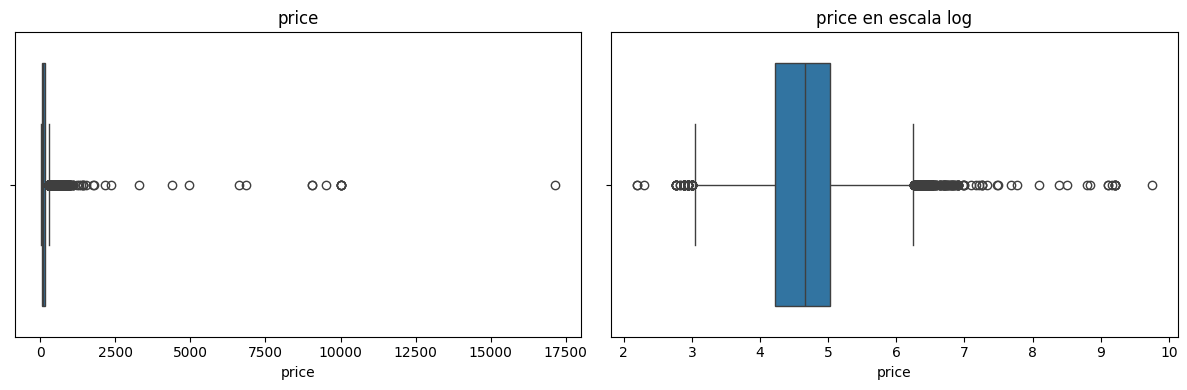

In [87]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=X_train["price"])
plt.title("price")

plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(X_train["price"]))
plt.title("price en escala log")

plt.tight_layout()
plt.show()

In [88]:
top_precio = X_train.nlargest(30, "price")[["host_id", "price", "room_type", "accommodates", "availability_365"]]
top_precio

,host_id,price,room_type,accommodates,availability_365
id,,,,,
18816591,1408525,17159.00,Entire home/apt,4,0
1250450623722567310,549699849,10000.00,Entire home/apt,6,363
917874776064641097,501482953,9999.00,Entire home/apt,2,107
917927860206046966,501482953,9999.00,Entire home/apt,6,10
917943830087375379,501482953,9999.00,Entire home/apt,4,107
918001311360817804,501482953,9999.00,Entire home/apt,4,71
2294171,11719928,9515.00,Entire home/apt,2,0
1060276046192183071,540456518,9059.00,Entire home/apt,4,362
1060276271097283207,540456518,9059.00,Entire home/apt,6,356


In [89]:
# Revenue de tres anuncios con precio extremo y calendario cerrado todo el año

y_train.loc[[18816591, 2294171, 1285464538933194999]]

id
18816591              720678.00
2294171                76120.00
1285464538933194999    25326.00
Name: estimated_revenue_l365d, dtype: float64

In [90]:
X_train["precio_por_persona"] = X_train["price"] / X_train["accommodates"]
X_train["precio_por_persona"].describe(percentiles=[0.95, 0.99])

count   14604.00
mean       42.78
std        87.01
min         1.25
50%        35.00
95%        80.50
99%       132.49
max      4999.50
Name: precio_por_persona, dtype: float64

In [91]:
# Filas afectadas según el umbral de precio por persona

for umbral in [150, 200, 300, 400, 500]:
    n = (X_train["precio_por_persona"] > umbral).sum()
    print(f"> {umbral} €/persona: {n} filas")

> 150 €/persona: 106 filas
> 200 €/persona: 57 filas
> 300 €/persona: 27 filas
> 400 €/persona: 22 filas
> 500 €/persona: 17 filas


In [92]:
# Anuncios por encima de 300 €/persona, los casos más extremos

X_train[X_train["precio_por_persona"] > 300][
    ["price", "accommodates", "room_type", "neighbourhood_group_cleansed", "availability_365", "host_id"]
].sort_values("price", ascending=False)

,price,accommodates,room_type,neighbourhood_group_cleansed,availability_365,host_id
id,,,,,,
18816591,17159.00,4,Entire home/apt,Latina,0,1408525
1250450623722567310,10000.00,6,Entire home/apt,Moncloa - Aravaca,363,549699849
917874776064641097,9999.00,2,Entire home/apt,Centro,107,501482953
917927860206046966,9999.00,6,Entire home/apt,Centro,10,501482953
917943830087375379,9999.00,4,Entire home/apt,Centro,107,501482953
918001311360817804,9999.00,4,Entire home/apt,Centro,71,501482953
2294171,9515.00,2,Entire home/apt,Centro,0,11719928
1060276271097283207,9059.00,6,Entire home/apt,Tetuán,356,540456518
1060276046192183071,9059.00,4,Entire home/apt,Tetuán,362,540456518


In [93]:
# Anuncios por encima de 300 €/persona, con la ocupación del año que mide el target

X_train[X_train["precio_por_persona"] > 300][
    ["price", "accommodates", "room_type", "neighbourhood_group_cleansed",
     "estimated_occupancy_l365d", "host_id"]
].sort_values("price", ascending=False)

,price,accommodates,room_type,neighbourhood_group_cleansed,estimated_occupancy_l365d,host_id
id,,,,,,
18816591,17159.00,4,Entire home/apt,Latina,42,1408525
1250450623722567310,10000.00,6,Entire home/apt,Moncloa - Aravaca,12,549699849
917874776064641097,9999.00,2,Entire home/apt,Centro,24,501482953
917927860206046966,9999.00,6,Entire home/apt,Centro,72,501482953
917943830087375379,9999.00,4,Entire home/apt,Centro,42,501482953
918001311360817804,9999.00,4,Entire home/apt,Centro,42,501482953
2294171,9515.00,2,Entire home/apt,Centro,8,11719928
1060276271097283207,9059.00,6,Entire home/apt,Tetuán,84,540456518
1060276046192183071,9059.00,4,Entire home/apt,Tetuán,6,540456518


In [94]:
# Revenue de los anuncios con precio absurdo: el target sale de multiplicar
# ese precio por la ocupación

extremos = X_train[X_train["precio_por_persona"] > 300].nlargest(9, "price")

extremos[["price", "estimated_occupancy_l365d"]].join(y_train.rename("revenue"))

,price,estimated_occupancy_l365d,revenue
id,,,
18816591,17159.00,42,720678.00
1250450623722567310,10000.00,12,120000.00
917874776064641097,9999.00,24,239976.00
917927860206046966,9999.00,72,719928.00
917943830087375379,9999.00,42,419958.00
918001311360817804,9999.00,42,419958.00
2294171,9515.00,8,76120.00
1060276046192183071,9059.00,6,54354.00
1060276271097283207,9059.00,84,760956.00


In [95]:
# Por encima de 500 €/persona no hay oferta real en Madrid (o muy poca): son precios configurados para no alquilar, que inflan el target al multiplicarse por la ocupación

mask_precio = X_train["precio_por_persona"] <= 500

print("Filas eliminadas:", (~mask_precio).sum())

X_train = X_train[mask_precio]
y_train = y_train[mask_precio]
y_train_log = y_train_log[mask_precio]

X_train.shape

Filas eliminadas: 17


(14587, 44)

In [96]:
# Columna de apoyo para el análisis: se recrea en feature engineering para train y test

X_train = X_train.drop(columns="precio_por_persona")

X_train.shape

(14587, 43)

El precio concentra el 99% de los anuncios por debajo de 552 € y llega a 17.159,
un factor de 31 respecto a ese percentil. Revisando los treinta valores más
altos aparece un patrón: varios anfitriones repiten el mismo precio exacto en
anuncios de capacidad distinta, como los cuatro de 9.999 € del host 501482953 o
los dos de 9.059 € del 540456518. Un piso para dos y otro para seis no valen lo
mismo, así que son precios aplicados en bloque para no alquilar, no tarifas
reales.

El efecto sobre el target es directo, porque el revenue se calcula multiplicando
precio por ocupación: 9.059 × 84 da 760.956 €, que es exactamente el máximo del
train. Las nueve filas con precio más alto concentran revenues de entre 54.000 y
760.000 € construidos sobre tarifas que nadie pagó.

El corte se aplica sobre el precio por plaza en lugar del precio absoluto, para
no penalizar a los pisos grandes de lujo, que son oferta legítima y deben estar
representados si la API va a recibir consultas de ese segmento. Por encima de
500 € por persona no hay oferta real en Madrid, y ese umbral elimina 17 filas
del train. En test no se aplica ningún filtro, porque la evaluación debe
enfrentarse a los datos tal como llegan.

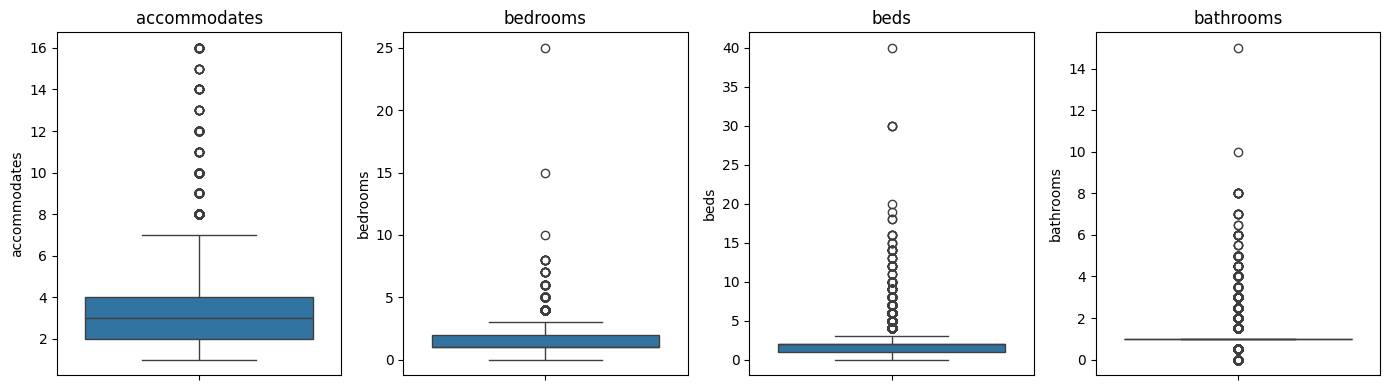

In [97]:
# Las cuatro variables de capacidad, para ver dónde están los extremos

cap_cols = ["accommodates", "bedrooms", "beds", "bathrooms"]

plt.figure(figsize=(14, 4))

for i, col in enumerate(cap_cols):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(y=X_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [98]:
# Combinaciones incoherentes: más camas que plazas, o muchas plazas sin camas

X_train[["accommodates", "bedrooms", "beds", "bathrooms", "room_type"]].nlargest(15, "beds")

,accommodates,bedrooms,beds,bathrooms,room_type
id,,,,,
1338973125565744182,16,1,40,2.00,Shared room
1404406490082028162,1,1,30,8.00,Shared room
1402918120228643048,16,1,30,8.00,Shared room
1406822142139959665,16,1,30,8.00,Shared room
1349744097766646177,16,1,20,6.00,Shared room
1244765837979335514,2,0,19,15.00,Private room
1315352272159454162,16,7,18,3.00,Private room
1234597607682551179,16,7,18,4.00,Entire home/apt
1291477986305817392,16,8,16,6.00,Entire home/apt


In [99]:
# beds no puede superar la capacidad declarada: son plazas que se venden

incoherentes = X_train["beds"] > X_train["accommodates"]

print("Filas con más camas que plazas:", incoherentes.sum())

X_train.loc[incoherentes, ["accommodates", "bedrooms", "beds", "bathrooms", "room_type"]].nlargest(15, "beds")

Filas con más camas que plazas: 249


,accommodates,bedrooms,beds,bathrooms,room_type
id,,,,,
1338973125565744182,16,1,40,2.00,Shared room
1404406490082028162,1,1,30,8.00,Shared room
1402918120228643048,16,1,30,8.00,Shared room
1406822142139959665,16,1,30,8.00,Shared room
1349744097766646177,16,1,20,6.00,Shared room
1244765837979335514,2,0,19,15.00,Private room
1315352272159454162,16,7,18,3.00,Private room
1234597607682551179,16,7,18,4.00,Entire home/apt
1338199361097963208,8,1,16,2.00,Shared room


In [100]:
# ¿Son un tipo concreto de alojamiento o están repartidas?

print(X_train.loc[incoherentes, "room_type"].value_counts())
print()
print((X_train.loc[incoherentes, "beds"] - X_train.loc[incoherentes, "accommodates"]).describe())

room_type
Private room       114
Entire home/apt     88
Shared room         47
Name: count, dtype: int64

count   249.00
mean      2.57
std       3.40
min       1.00
25%       1.00
50%       1.00
75%       3.00
max      29.00
dtype: float64


In [101]:
# Solo los casos sin explicación posible: más del doble de camas que plazas

mask_camas = X_train["beds"] <= X_train["accommodates"] * 2

print("Filas eliminadas:", (~mask_camas).sum())

X_train.loc[~mask_camas, ["accommodates", "bedrooms", "beds", "bathrooms", "room_type"]]

Filas eliminadas: 68


,accommodates,bedrooms,beds,bathrooms,room_type
id,,,,,
1463988292976192164,2,1,6,2.00,Entire home/apt
51647382,1,2,3,1.00,Private room
832979982318294932,1,1,8,4.00,Shared room
1404406490082028162,1,1,30,8.00,Shared room
52897821,1,1,4,4.00,Shared room
...,...,...,...,...,...
1121112637448925263,2,5,6,2.00,Private room
1136035927061531038,1,1,14,1.00,Shared room
839123661155092383,3,1,10,2.50,Shared room


In [102]:
# Eliminamos las 68 filas incoherentes

X_train = X_train[mask_camas]
y_train = y_train[mask_camas]
y_train_log = y_train_log[mask_camas]

X_train.shape

(14519, 43)

Las cuatro variables de capacidad muestran colas largas, pero el tamaño por sí
solo no indica error: un piso de 16 plazas con 7 dormitorios es oferta real, y
un hostal con 30 camas también. Lo que sí es contradictorio es la relación entre
ellas, y en concreto los anuncios que declaran más camas que plazas
disponibles.

Hay 249 filas en esa situación, aunque la mediana de la diferencia es de una
sola cama, lo que se explica por sofás cama o supletorias que se cuentan como
plaza en un campo y no en el otro. El corte se aplica solo donde la
contradicción no tiene lectura posible, por encima del doble de camas que
plazas: 68 filas, casi todas habitaciones compartidas o privadas que declaran
una o dos plazas y las camas del establecimiento completo.

In [103]:
# Anuncios que declaran cero baños o cero dormitorios

print("Con 0 baños:", (X_train["bathrooms"] == 0).sum())
print("Con 0 dormitorios:", (X_train["bedrooms"] == 0).sum())

Con 0 baños: 104
Con 0 dormitorios: 1102


In [104]:
# ¿Qué tipo de alojamiento declara 0 dormitorios?

print(X_train.loc[X_train["bedrooms"] == 0, "property_type"].value_counts().head(10))
print()
print(X_train.loc[X_train["bedrooms"] == 0, "room_type"].value_counts())

property_type
Entire rental unit                   877
Entire loft                           66
Private room in rental unit           54
Room in aparthotel                    16
Entire serviced apartment             16
Entire home                           10
Entire condo                          10
Private room in guesthouse            10
Private room in home                   9
Private room in bed and breakfast      4
Name: count, dtype: int64

room_type
Entire home/apt    1009
Private room         90
Shared room           2
Hotel room            1
Name: count, dtype: int64


In [105]:
X_train.loc[X_train["bathrooms"] == 0, "bathrooms_text"].value_counts(dropna=False)

bathrooms_text
0 baths           54
0 shared baths    49
NaN                1
Name: count, dtype: int64

In [106]:
print("Con 0 camas:", (X_train["beds"] == 0).sum())

Con 0 camas: 315


In [107]:
# Ni el alojamiento entero ni la habitación pueden tener cero dormitorios, baños o camas: es la unidad mínima de lo que se alquila. Al ser una corrección fija,
# sin parámetro calculado sobre train, se aplica también a test. Los medios baños se redondean hacia arriba: lo que interesa es cuántas piezas
# de baño hay, no si una tiene ducha

for df_ in [X_train, X_test]:
    df_["bathrooms"] = np.ceil(df_["bathrooms"])
    for col in ["bedrooms", "bathrooms", "beds"]:
        df_.loc[df_[col] == 0, col] = 1
        df_[col] = df_[col].astype(int)

print(X_train[["bedrooms", "bathrooms", "beds"]].min())

bedrooms     1
bathrooms    1
beds         1
dtype: int64


Aparte de la coherencia entre variables, hay anuncios que declaran cero
dormitorios, cero baños o cero camas: 1.102, 104 y 315 respectivamente. No son
incoherencias internas sino campos mal rellenados, porque lo que se alquila
tiene al menos un espacio para dormir, una cama y una pieza de baño, así que los
tres se corrigen a 1. Los medios baños se redondean hacia arriba, ya que lo
relevante es cuántas piezas hay y no si una de ellas carece de ducha. Al ser
correcciones fijas, sin parámetro estimado sobre train, se aplican también a
test.

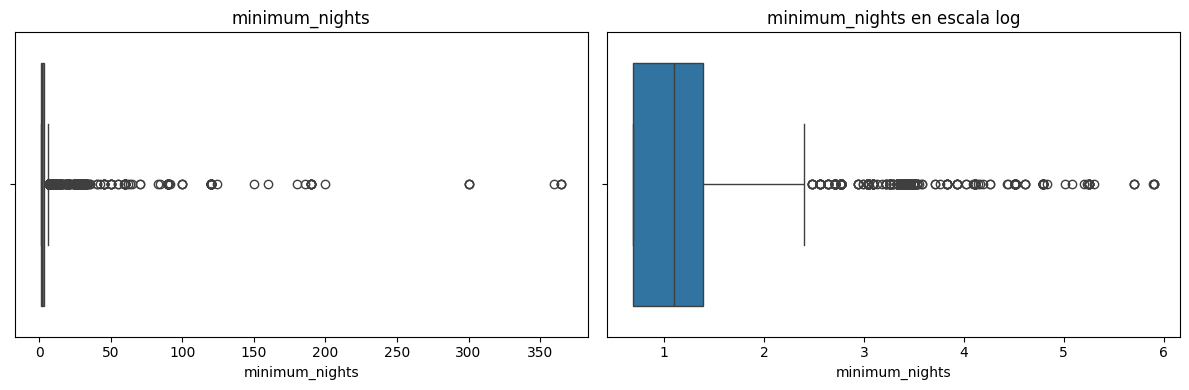

In [108]:
# Estancia mínima: el 99% está en 32 noches y el máximo en 365

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=X_train["minimum_nights"])
plt.title("minimum_nights")

plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(X_train["minimum_nights"]))
plt.title("minimum_nights en escala log")

plt.tight_layout()
plt.show()

In [109]:
X_train["minimum_nights"].value_counts().head(15)

minimum_nights
1     6562
2     3119
3     1810
4      560
30     497
5      410
7      288
31     207
28     170
6      122
32     103
20     102
10     102
15      96
14      56
Name: count, dtype: int64

In [110]:
# ¿Facturan distinto los anuncios de estancia mínima larga?

largos = X_train["minimum_nights"] >= 28

print("Anuncios con mínimo de 28 noches o más:", largos.sum())
print("Revenue mediano:", y_train[largos].median())
print("Revenue mediano resto:", y_train[~largos].median())

Anuncios con mínimo de 28 noches o más: 1147
Revenue mediano: 14400.0
Revenue mediano resto: 9720.0


La estancia mínima concentra el grueso entre una y siete noches, pero hay un
segundo grupo alrededor del mes: 1.147 anuncios piden 28 noches o más. No son
errores sino alquiler de temporada, y se conservan porque la API debe cubrir ese
caso. El máximo de 365 es el tope natural del campo.

Queda una dependencia anotada: Inside Airbnb usa `minimum_nights` en el cálculo
de la ocupación cuando supera la estancia media que asume por defecto, así que
en estos anuncios parte del revenue se construye con esa variable.

In [111]:
# Las valoraciones van de 1 a 5: comprobamos que no haya ceros inválidos

review_cols = [c for c in X_train.columns if "review_scores" in c]

X_train[review_cols].min()

review_scores_rating          1.00
review_scores_accuracy        1.00
review_scores_cleanliness     1.00
review_scores_checkin         1.00
review_scores_communication   1.00
review_scores_location        1.00
review_scores_value           1.00
dtype: float64

In [112]:
# host_id ya cumplió su papel al detectar los precios repetidos por anfitrión, es un identificador sin capacidad predictiva

X_train = X_train.drop(columns="host_id")
X_test = X_test.drop(columns="host_id")

X_train.shape

(14519, 42)

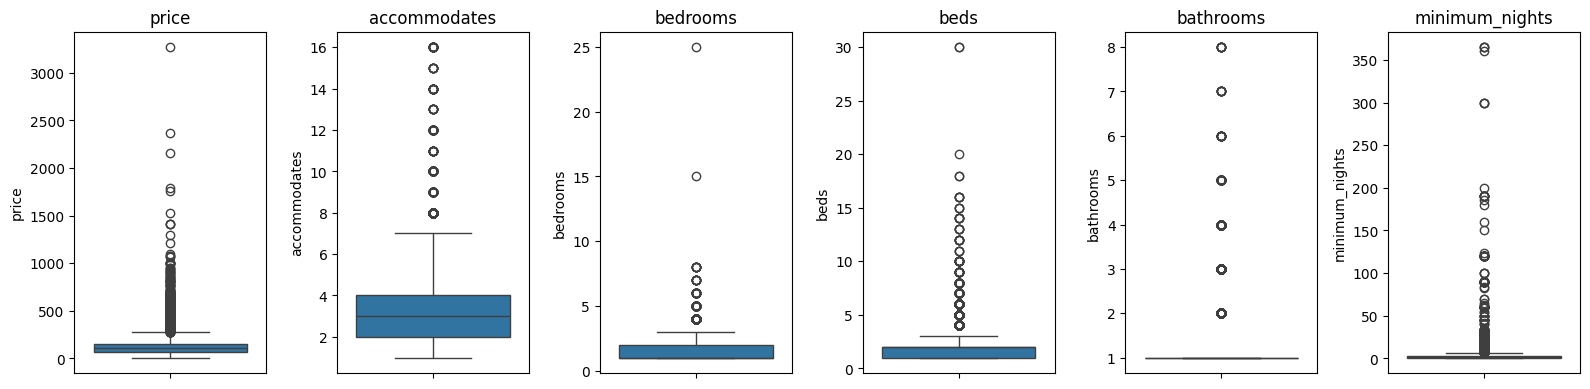

In [113]:
# Estado de las variables tratadas tras los filtros y correcciones

check_cols = ["price", "accommodates", "bedrooms", "beds", "bathrooms", "minimum_nights"]

plt.figure(figsize=(16, 4))

for i, col in enumerate(check_cols):
    plt.subplot(1, 6, i + 1)
    sns.boxplot(y=X_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Tras los filtros y correcciones, el train pasa de 14.604 a 14.519 filas, un 0,6%
menos. Los boxplots finales confirman que las variables de capacidad arrancan en
1 y que el precio máximo baja de 17.159 a unos 3.270 euros. Las siete
valoraciones tienen mínimo 1, dentro de la escala válida, así que no requieren
tratamiento.

Queda fuera `host_id`, que se conservaba desde la sección 6 únicamente para
detectar los precios repetidos por anfitrión. Las colas que siguen visibles en
los gráficos corresponden a oferta real: pisos grandes, alojamientos de lujo y
alquiler de temporada.

#### 10. Feature engineering

Varias columnas guardan información que el modelo no puede usar tal como viene:
fechas en texto, listas serializadas y campos libres de los que hay que extraer
una señal concreta. Aquí se construyen esas variables y se eliminan las columnas
de origen. Los encodings de barrio y distrito se dejan para el pipeline de
modelado, porque el target encoding debe calcularse dentro de cada fold para no
introducir leakage.

In [114]:
# La antigüedad se mide respecto al último scraping (14/09/2025), no a la fecha de ejecución del notebook

fecha_ref = pd.Timestamp("2025-09-14")

for df_ in [X_train, X_test]:
    df_["host_since"] = pd.to_datetime(df_["host_since"], errors="coerce")
    df_["antiguedad_host"] = (fecha_ref - df_["host_since"]).dt.days

X_train["antiguedad_host"].describe()

count   14445.00
mean     2357.60
std      1408.74
min        18.00
25%      1096.00
50%      2358.00
75%      3531.00
max      5875.00
Name: antiguedad_host, dtype: float64

In [115]:
nulos = X_train.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

license            8614
host_location      4700
host_since           74
antiguedad_host      74
bathrooms_text       12
dtype: int64

In [116]:
# Los 74 anuncios sin datos de anfitrión toman la antigüedad mediana del train

mediana_antiguedad = X_train["antiguedad_host"].median()

X_train["antiguedad_host"] = X_train["antiguedad_host"].fillna(mediana_antiguedad)
X_test["antiguedad_host"] = X_test["antiguedad_host"].fillna(mediana_antiguedad)

X_train["antiguedad_host"].isna().sum()

np.int64(0)

In [117]:
# Relación entre las fechas de reseña y el target, antes de decidir si se conservan

first = pd.to_datetime(X_train["first_review"], errors="coerce")
last = pd.to_datetime(X_train["last_review"], errors="coerce")

fecha_ref = pd.Timestamp("2025-09-14")

dias_ultima = (fecha_ref - last).dt.days
vida_resenas = (last - first).dt.days

print("Correlación con el target (log):")
print("dias desde la última reseña:", y_train_log.corr(dias_ultima).round(3))
print("vida de las reseñas:", y_train_log.corr(vida_resenas).round(3))
print()
print(dias_ultima.describe())

Correlación con el target (log):
dias desde la última reseña: -0.406
vida de las reseñas: 0.304

count   14519.00
mean       80.48
std        93.05
min         0.00
25%        14.00
50%        45.00
75%       105.00
max       549.00
Name: last_review, dtype: float64


De las tres fechas solo se conserva `host_since`, convertida a
`antiguedad_host`: días entre el registro del anfitrión y el último scraping
(14/09/2025). La referencia se fija en esa fecha y no en la de ejecución del
notebook, para que sea comparable entre filas. Los 74 anuncios sin datos de
anfitrión toman la mediana del train.

`first_review` y `last_review` se descartan. Correlacionan con el target
(-0,41), pero porque lo delatan: un anuncio con reseña reciente es uno que se
está alquilando. Además quien consulta la API proyecta un piso que aún no ha
publicado y no tiene esas fechas. Se eliminan con el bloque de reseñas en la
sección siguiente.

In [118]:
X_train["bathrooms_text"].value_counts(dropna=False).head(15)

bathrooms_text
1 bath              8038
2 baths             1990
1 shared bath       1685
1 private bath       976
1.5 baths            386
2 shared baths       275
3 baths              253
1.5 shared baths     190
Shared half-bath     127
2.5 baths            122
3 shared baths        75
4 baths               55
0 baths               55
0 shared baths        50
Half-bath             41
Name: count, dtype: int64

In [119]:
# Marca los anuncios que declaran baño compartido. El número de baños ya está en la columna bathrooms, así que de aquí solo interesa esa distinción

for df_ in [X_train, X_test]:

    df_["bano_compartido"] = (df_["bathrooms_text"].str.lower().str.contains("shared", na= False).astype(int))

X_train["bano_compartido"].value_counts()

bano_compartido
0    12040
1     2479
Name: count, dtype: int64

In [120]:
# Solo interesa si el anuncio declara licencia o no: los 7.148 valores rellenados mezclan códigos reales, "Exempt", "En proceso" y hasta una plantilla sin completar

for df_ in [X_train, X_test]:
    
    df_["declara_licencia"] = df_["license"].notna().astype(int)

X_train["declara_licencia"].value_counts()

declara_licencia
0    8614
1    5905
Name: count, dtype: int64

In [121]:
X_train["host_location"].value_counts(dropna=False).head(15)

host_location
Madrid, Spain                 8835
NaN                           4700
Barcelona, Spain               165
Spain                          106
London, United Kingdom          41
Las Rozas, Spain                25
Buenos Aires, Argentina         19
Majadahonda, Spain              19
Zarzalejo, Spain                16
Rivas-Vaciamadrid, Spain        15
Mexico City, Mexico             14
Community of Madrid, Spain      13
Pozuelo de Alarcón, Spain       12
Málaga, Spain                   11
Springe, Germany                10
Name: count, dtype: int64

In [122]:
# El anfitrión declara residir en Madrid. Los 4.700 nulos cuentan como no, porque quien no indica ubicación tampoco confirma cercanía

for df_ in [X_train, X_test]:
    
    df_["host_en_madrid"] = (df_["host_location"].str.lower().str.contains("madrid", na=False).astype(int))

X_train["host_en_madrid"].value_counts()

host_en_madrid
1    8873
0    5646
Name: count, dtype: int64

In [123]:
# ¿Facturan igual los que no declaran ubicación que los que declaran vivir fuera?

sin_dato = X_train["host_location"].isna()
fuera = X_train["host_location"].notna() & (X_train["host_en_madrid"] == 0)
dentro = X_train["host_en_madrid"] == 1

print("Sin dato:", y_train[sin_dato].median(), "|", sin_dato.sum())
print("Fuera de Madrid:", y_train[fuera].median(), "|", fuera.sum())
print("En Madrid:", y_train[dentro].median(), "|", dentro.sum())

Sin dato: 7875.0 | 4700
Fuera de Madrid: 11807.0 | 946
En Madrid: 11328.0 | 8873


In [124]:
# La ubicación declarada no separa el revenue (11.328 € en Madrid frente a 11.807 € fuera), pero no declararla sí: esos anuncios facturan 7.875 €

for df_ in [X_train, X_test]:
    
    df_["declara_ubicacion"] = df_["host_location"].notna().astype(int)

X_train["declara_ubicacion"].value_counts()

declara_ubicacion
1    9819
0    4700
Name: count, dtype: int64

Tres columnas de texto se convierten en binarias. De `bathrooms_text` interesa
solo si el baño es compartido, porque el número ya está en `bathrooms`: son
2.479 anuncios, un 17%. De `license` basta con saber si se declara algo, ya que
los valores rellenados mezclan códigos reales con "Exempt", "En proceso" y
plantillas sin completar; el nulo aquí no es un dato ausente sino una
declaración vacía.

`host_location` da dos variables en lugar de una. La residencia declarada no
separa el revenue, con una mediana de 11.328 € para los anfitriones en Madrid
frente a 11.807 € para los de fuera, así que la hipótesis de que la cercanía
mejora la gestión no se sostiene. Lo que sí separa es no declarar ubicación:
esos 4.700 anuncios facturan 7.875 €, un 33% menos. Se conservan ambas,
`host_en_madrid` y `declara_ubicacion`, aunque la primera queda pendiente de
confirmar su aporte en la fase de modelado.

In [125]:
X_train["amenities"].iloc[0]

'["Washer", "Hair dryer", "Bed linens", "Cooking basics", "Wifi", "Dishes and silverware", "Long term stays allowed", "Hot water", "Noise decibel monitors on property", "Hangers", "Air conditioning", "Dining table", "Kitchen", "Ceiling fan", "Coffee maker: Nespresso", "Sobres shampoo", "TV", "Hot water kettle", "Wine glasses", "Room-darkening shades", "Iron", "Smoke alarm", "Carbon monoxide alarm", "Paid street parking off premises", "Fire extinguisher", "Radiant heating"]'

In [126]:
# La columna guarda una lista serializada como texto: literal_eval la convierte en lista real para poder contar sus elementos

for df_ in [X_train, X_test]:
    df_["n_amenities"] = df_["amenities"].apply(ast.literal_eval).apply(len)

X_train["n_amenities"].describe()

count   14519.00
mean       28.99
std        12.55
min         0.00
25%        21.00
50%        29.00
75%        37.00
max        86.00
Name: n_amenities, dtype: float64

In [127]:
(X_train["n_amenities"] == 0).sum()

np.int64(3)

In [128]:
# Precio por plaza: normaliza la tarifa según la capacidad, que es como se compara la oferta entre alojamientos de distinto tamaño

for df_ in [X_train, X_test]:
    df_["precio_por_persona"] = df_["price"] / df_["accommodates"]

X_train["precio_por_persona"].describe()

count   14519.00
mean       40.47
std        25.12
min         1.25
25%        25.67
50%        35.00
75%        48.50
max       499.50
Name: precio_por_persona, dtype: float64

In [129]:
# Las cuatro categorías reales tienen orden natural. "Unknown" va a -1 para no situarlo artificialmente dentro de la escala

orden_respuesta = {
    "within an hour": 0,
    "within a few hours": 1,
    "within a day": 2,
    "a few days or more": 3,
    "Unknown": -1,
}

for df_ in [X_train, X_test]:
    df_["respuesta_ord"] = df_["host_response_time"].map(orden_respuesta)

X_train["respuesta_ord"].value_counts().sort_index()

respuesta_ord
-1      553
 0    11113
 1     1668
 2      882
 3      303
Name: count, dtype: int64

In [130]:
# Columnas ya representadas por las features creadas arriba

cols_origen = [
    "host_since",
    "bathrooms_text",
    "license",
    "host_location",
    "amenities",
    "host_response_time",
]

X_train = X_train.drop(columns=cols_origen)
X_test = X_test.drop(columns=cols_origen)

X_train.shape

(14519, 44)

In [131]:
print(X_train.shape, X_test.shape)
print(set(X_train.columns) == set(X_test.columns))

(14519, 44) (3623, 44)
True


In [132]:
print(X_train.isna().sum().sum())
print(X_train.select_dtypes(include="object").columns.tolist())

0
['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'first_review', 'last_review', 'instant_bookable']


In [133]:
# Las cuatro binarias vienen como "t"/"f": pasan a 1/0

bin_cols = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "instant_bookable",
]

for df_ in [X_train, X_test]:
    for col in bin_cols:
        df_[col] = (df_[col] == "t").astype(int)

X_train[bin_cols].mean().round(3)

host_is_superhost        0.29
host_has_profile_pic     0.97
host_identity_verified   0.96
instant_bookable         0.51
dtype: float64

La sección deja el train en 44 columnas sin ningún nulo. Se han creado ocho
variables: `antiguedad_host`, `bano_compartido`, `declara_licencia`,
`host_en_madrid`, `declara_ubicacion`, `n_amenities`, `precio_por_persona` y
`respuesta_ord`, y se han eliminado las seis columnas de origen que ya quedaban
representadas por ellas.

El conteo de servicios va de 0 a 86, con una mediana de 29. La escala ordinal de
respuesta queda muy desbalanceada, con un 77% de anfitriones en el tramo más
rápido, así que su capacidad de discriminar será limitada. Las cuatro binarias
del anfitrión pasan de "t"/"f" a 1/0; dos de ellas, `host_has_profile_pic` y
`host_identity_verified`, tienen más del 95% de los anuncios en el mismo valor y
quedan pendientes de revisar su aporte en la fase de modelado.

Las cuatro categóricas restantes (barrio, distrito, `room_type` y
`property_type`) se codifican dentro del pipeline, no aquí.

#### 11. Eliminación de variables con leakage

Las variables que se retiran aquí no se van por ser redundantes ni por aportar
poco, sino por lo contrario: son las que más correlacionan con el objetivo,
porque el objetivo se construye a partir de ellas.

In [134]:
# Las variables que construyen el target y el historial de reseñas del anuncio

leakage_drop = ["estimated_occupancy_l365d", 
                "number_of_reviews",
                "number_of_reviews_ltm",
                "number_of_reviews_ly",
                "number_of_reviews_l30d",
                "reviews_per_month",
                "first_review",
                "last_review"]

X_train = X_train.drop(columns= leakage_drop, errors="ignore")
X_test = X_test.drop(columns= leakage_drop, errors="ignore")

X_train.shape

(14519, 36)

In [135]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include= "object").columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))
print(X_train.shape, X_test.shape)
print(set(X_train.columns) == set(X_test.columns))

Numéricas: 32
Categóricas: 4
(14519, 36) (3623, 36)
True


In [136]:
print(sorted(num_cols))
print()
print(sorted(cat_cols))

['accommodates', 'antiguedad_host', 'availability_365', 'bano_compartido', 'bathrooms', 'bedrooms', 'beds', 'calculated_host_listings_count', 'declara_licencia', 'declara_ubicacion', 'host_acceptance_rate', 'host_en_madrid', 'host_has_profile_pic', 'host_identity_verified', 'host_is_superhost', 'host_response_rate', 'instant_bookable', 'latitude', 'longitude', 'minimum_nights', 'n_amenities', 'precio_por_persona', 'price', 'respuesta_ord', 'review_scores_accuracy', 'review_scores_checkin', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_rating', 'review_scores_value', 'sin_datos_respuesta']

['neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type']


In [137]:
data_report(X_train).T

,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
COL_N,,,,
host_response_rate,float64,0.00,85,0.59
host_acceptance_rate,float64,0.00,101,0.70
host_is_superhost,int64,0.00,2,0.01
host_has_profile_pic,int64,0.00,2,0.01
host_identity_verified,int64,0.00,2,0.01
neighbourhood_cleansed,object,0.00,127,0.87
neighbourhood_group_cleansed,object,0.00,21,0.14
latitude,float64,0.00,10623,73.17
longitude,float64,0.00,10314,71.04


El bloque que se retira aquí reúne las ocho variables con mayor correlación con el objetivo: `estimated_occupancy_l365d`, los cinco recuentos de reseñas (`number_of_reviews`, `number_of_reviews_ltm`, `number_of_reviews_ly`, `number_of_reviews_l30d` y `reviews_per_month`) y las dos fechas, `first_review` y `last_review`.

La ocupación estimada es factor directo del target, que Inside Airbnb calcula multiplicándola por el precio. Los recuentos de reseñas son el insumo con el que esa ocupación se deriva. Las dos fechas no entran en el cálculo, pero informan de lo mismo: un anuncio con reseña reciente es un anuncio que se está alquilando, y su correlación con el revenue (-0,41) mide esa circunstancia, no una característica del alojamiento.

A este criterio se suma otro que resulta más decisivo y que viene del uso previsto del modelo. Quien consulta la API está proyectando el rendimiento de un piso que todavía no ha publicado: no tiene ocupación del último año, ni reseñas, ni fechas de reseña. Una variable que el usuario no puede aportar no sirve como predictor por buena que sea su correlación. Bajo esa misma lógica quedan señaladas las siete `review_scores`, que siguen en el dataset y se resolverán en la fase de modelado.

El train pasa de 44 a 36 columnas, 32 numéricas y 4 categóricas, sin nulos y alineado con el test. Con el bloque de la fórmula fuera, los predictores restantes describen el alojamiento y su anfitrión, no su historial comercial, y las métricas caerán de forma notable respecto a cualquier versión que incluyera estas variables. Ese descenso es la consecuencia esperada de medir lo que el modelo puede predecir de verdad.

#### 12. Métrica, validación y comparación de modelos

La sección arranca retirando las siete valoraciones por el mismo criterio de la anterior, fija el protocolo con el que se evalúa cualquier candidato y compara tres modelos bajo ese protocolo.

El objetivo se modela en escala logarítmica, `y_train_log = log1p(y_train)`, de modo que el error que minimiza el entrenamiento es relativo y no absoluto. Eso cambia qué significa la métrica: un RMSE calculado sobre esa escala mide error proporcional, así que se reporta también la lectura en euros deshaciendo la transformación con `expm1`, teniendo en cuenta que esa inversa devuelve aproximadamente la mediana condicional y no la media.

In [138]:
# Las valoraciones son resultado de operar el alojamiento, no una característica que el usuario pueda aportar

review_drop = [c for c in X_train.columns if "review_scores" in c]

X_train = X_train.drop(columns=review_drop, errors="ignore")
X_test = X_test.drop(columns=review_drop, errors="ignore")

X_train.shape

(14519, 29)

In [139]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))
print(X_train.shape, X_test.shape)
print(set(X_train.columns) == set(X_test.columns))

Numéricas: 25
Categóricas: 4
(14519, 29) (3623, 29)
True


Se comparan cuatro candidatos bajo el mismo protocolo.

El primero es un baseline que ignora las features y predice siempre la mediana del train. Marca el suelo contra el que se mide si las variables aportan algo.

Ridge actúa como referencia lineal, con regularización L2 porque varias features del dataset están correlacionadas entre sí.  

Random Forest y XGBoost cubren las relaciones no lineales y las interacciones, por bagging el primero y por boosting el segundo.

Los cuatro se evalúan con el mismo K-Fold de cinco particiones y la misma métrica. El preprocesado viaja dentro del pipeline  

de modo que los encodings se calculan en cada fold con los datos de entrenamiento de ese fold y no con el train completo.

In [140]:
cv = KFold(n_splits= 5, shuffle= True, random_state=42)

Cada grupo de columnas recibe un tratamiento distinto.

**Numéricas (25).** Estandarizadas a media 0 y desviación 1. Ridge lo necesita: sin escalar, penaliza los coeficientes según la unidad de medida y no según su aporte.  

Los árboles no lo requieren, pero tampoco les perjudica.

**`room_type` y `property_type`.** One-hot. Sus categorías no tienen orden, así que codificarlas como enteros introduciría una jerarquía inexistente.

**Barrio y distrito.** Target encoding. Con 127 barrios el one-hot generaría columnas casi vacías, y 43 de ellos no llegan a 30 anuncios.  

El encoder los sustituye por el revenue medio de su grupo, suavizado hacia la media global cuanto menos anuncios tenga, y calcula el valor de cada fila excluyéndola del promedio.

In [143]:
# Cada grupo de columnas recibe su propio tratamiento: escalado para las numéricas (lo necesita Ridge), one-hot para las de pocas categorías y target encoding suavizado para los 127 barrios

cat_onehot = ["room_type", "property_type"]
cat_target = ["neighbourhood_cleansed", "neighbourhood_group_cleansed"]

preprocesador = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_onehot),
    ("target", TargetEncoder(random_state=42), cat_target),
])

Cuatro pipelines con el mismo preprocesador y distinto estimador. El baseline es la excepción: no lleva preprocesado porque ignora las features.

**Ridge.** `alpha=10.0` como punto de partida. Controla cuánta penalización recibe el tamaño de los coeficientes, y su valor definitivo se busca en la sección siguiente.

**Random Forest.** 400 árboles, profundidad sin limitar. Cada árbol ve una muestra distinta de filas y columnas, y la predicción es el promedio de todos.

**XGBoost.** 600 árboles con `learning_rate=0.05`: muchos pasos pequeños generalizan mejor que pocos grandes. `max_depth=6` limita la complejidad de cada árbol, y `subsample` y `colsample_bytree` en 0,9 dejan fuera un 10% de filas y columnas en cada uno para reducir el sobreajuste.

Los tres arrancan con valores conservadores que sirven de referencia. La optimización se hace en la sección 13, una vez elegido el candidato.

In [144]:
pipelines = {
    "Baseline (mediana)": DummyRegressor(strategy="median"),

    "Ridge": Pipeline([
        ("prep", preprocesador),
        ("model", Ridge(alpha=10.0)),
    ]),

    "RandomForest": Pipeline([
        ("prep", preprocesador),
        ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
    ]),

    "XGBoost": Pipeline([
        ("prep", preprocesador),
        ("model", XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6,
                               subsample=0.9, colsample_bytree=0.9,
                               random_state=42, n_jobs=-1)),
    ]),
}

In [146]:
# Mismo CV y misma métrica para los cuatro. El scoring viene en negativo porque sklearn siempre maximiza

resultados = {}

for nombre, modelo in pipelines.items():
    scores = cross_val_score(modelo, X_train, y_train_log, cv=cv,
                             scoring="neg_root_mean_squared_error")
    resultados[nombre] = -scores.mean()

    print(f"{nombre}: RMSE {resultados[nombre]:.3f} (±{scores.std():.3f})")

Baseline (mediana): RMSE 1.327 (±0.015)
Ridge: RMSE 1.001 (±0.004)
RandomForest: RMSE 0.866 (±0.005)
XGBoost: RMSE 0.853 (±0.003)


Resultados del CV, RMSE sobre el target en escala logarítmica.

| Modelo | RMSE | Desviación entre folds |
|---|---|---|
| Baseline (mediana) | 1,327 | 0,015 |
| Ridge | 1,001 | 0,004 |
| Random Forest | 0,866 | 0,005 |
| XGBoost | 0,853 | 0,003 |

El baseline marca el suelo: 1,327 es el error de no usar ninguna feature. XGBoost lo reduce a 0,853, un 36% menos, así que las variables que quedaron tras retirar el bloque de la fórmula sí aportan señal, aunque de forma modesta.

Ridge recorta por sí solo la mitad de esa mejora, lo que indica que buena parte de la relación es lineal. Los dos modelos de árboles añaden el resto y quedan separados por 0,013, una diferencia pequeña frente a lo que los separa del baseline.

Las desviaciones entre folds están entre 0,003 y 0,015 en los cuatro casos, así que ninguno de los resultados depende de cómo cayó la partición.

Pasa a la fase de optimización XGBoost, por ser el mejor de los cuatro y el más rápido de entrenar de los dos candidatos de árboles.

La lectura del error en euros se deja para la evaluación final, donde se reportan las métricas sobre test en la escala original.

### 13–14) Protocolo de evaluación: Cross-Validation (CV)

Antes de comparar modelos, fijamos un **único protocolo de validación** para que la comparación sea justa:
- Usaremos **K-Fold CV** (k=5) sobre `X_train`/`y_train`.
- `shuffle=True` mezcla los datos antes de partirlos (útil si no hay orden temporal).
- `random_state=42` garantiza reproducibilidad.

**Regla clave:** todos los modelos se evalúan con **el mismo CV** y la misma métrica (RMSE en `revenue_log`).

In [ ]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

## 14) Pipelines por modelo
Creamos **un pipeline por modelo** para evitar leakage en CV y comparar justo.  
El preprocesado es común (ej. imputación) y solo cambia el estimador.  

### Modelos a comparar
Probamos tres enfoques para cubrir distintos niveles de complejidad:
- **Ridge (L2)**: baseline lineal fuerte. La regularización L2 reduce overfitting y ayuda cuando hay colinealidad y muchas features.
- **Random Forest**: captura no linealidades e interacciones sin requerir escalado; suele ser robusto.
- **XGBoost**: boosting, normalmente muy competitivo en datos tabulares al modelar patrones complejos.

**Haremos un CV para cada modelos y luego nos quedaremos con el mejor**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

pipelines = {"Ridge": Pipeline([("imputer", SimpleImputer(strategy="median")),
                                ("scaler", StandardScaler()),
                                ("model", Ridge(alpha= 10.0))]),
                                
                                "RandomForest": Pipeline([("imputer", SimpleImputer(strategy="median")),
                                                          ("model", RandomForestRegressor(n_estimators= 400,
                                                                                          random_state= 42,
                                                                                          n_jobs= -1))]),
                                                              
                                "XGBoost": Pipeline([("imputer", SimpleImputer(strategy="median")),
                                                     ("model", XGBRegressor(n_estimators= 600,
                                                                            learning_rate= 0.05,
                                                                            max_depth= 6,
                                                                            subsample= 0.9,
                                                                            colsample_bytree= 0.9,
                                                                            reg_lambda= 1.0,
                                                                            random_state= 42,
                                                                            n_jobs= -1))])
                                                                                           }

results = {}

for name, pipe in pipelines.items():
    rmse = -cross_val_score(pipe, X_train, y_train, cv= cv, scoring= "neg_root_mean_squared_error").mean()
    results[name] = rmse

    print(f"CV RMSE (log) {name}: {rmse:.3f}")

best_name = min(results, key= results.get)
best_pipe = pipelines[best_name]

print(f"\nMejor por CV (log RMSE): {best_name} -> {results[best_name]:.3f}")

### Modelado: baseline y comparativa (con validación cruzada)

Para comparar modelos de forma justa, usamos el **mismo preprocesado** (imputación; escalado solo para modelos lineales), el mismo **K-Fold CV** y la misma métrica (**RMSE sobre `revenue_log`**).

**Baseline (referencia mínima):**
- **Ridge (L2)** actúa como baseline lineal robusto: es simple, rápido y suele rendir bien con muchas variables y posible colinealidad.

**Modelos comparados:**
- **Ridge (L2)**: referencia lineal.
- **Random Forest**: captura no linealidades e interacciones sin requerir escalado.
- **XGBoost**: boosting, normalmente muy competitivo en datos tabulares al combinar muchos árboles “débiles” con regularización.

**Resultados (CV RMSE en `revenue_log`, menor es mejor):**
- Ridge: 1.273  
- Random Forest: 0.068  
- XGBoost: 0.054  

Con estos resultados, **XGBoost** fue el mejor modelo en CV y lo seleccionamos como candidato para la fase de **optimización de hiperparámetros** y evaluación final.

> Nota: reportamos RMSE en escala logarítmica porque modelamos `revenue_log = log1p(revenue)` para reducir asimetría y el impacto de outliers.

### XGBoost: hiperparámetros elegidos (configuración base, sin tuning)
Usamos una configuración **conservadora** para obtener buen rendimiento sin optimización exhaustiva:

- `n_estimators=600` + `learning_rate=0.05`: más árboles con un paso de aprendizaje pequeño → suele generalizar mejor que pocos árboles con learning rate alto.
- `max_depth=6`: profundidad moderada para capturar no linealidades sin volver el modelo demasiado complejo.
- `subsample=0.9` y `colsample_bytree=0.9`: “submuestreo” de filas y columnas en cada árbol para reducir overfitting y mejorar robustez.
- `reg_lambda=1.0`: regularización L2 estándar para penalizar complejidad y estabilizar el modelo.
- `random_state=42`: reproducibilidad de resultados.
- `n_jobs=-1`: usa todos los núcleos disponibles para acelerar el entrenamiento.

Estos valores funcionan como **baseline fuerte**; la optimización de hiperparámetros se realizará en el siguiente bloque del proyecto.

In [ ]:
y_test_eur = np.expm1(y_test)
print("Median revenue (test):", np.median(y_test_eur))
print("Mean revenue (test):  ", np.mean(y_test_eur))

In [ ]:
y_test_eur = np.expm1(y_test)
for p in [50, 75, 90, 95, 99]:
    print(p, np.percentile(y_test_eur, p))
print("max", y_test_eur.max())

### Chequeo rápido del target (escala original)
Antes de interpretar las métricas, deshacemos `log1p` con `expm1` para ver el revenue anual en euros.  
Calculamos **media, mediana y percentiles** del revenue en test para entender su magnitud típica y su dispersión.

### Modelos a comparar
Probamos tres enfoques para cubrir distintos niveles de complejidad:
- **Ridge (L2)**: baseline lineal fuerte. La regularización L2 reduce overfitting y ayuda cuando hay colinealidad y muchas features.
- **Random Forest**: captura no linealidades e interacciones sin requerir escalado; suele ser robusto.
- **XGBoost**: boosting, normalmente muy competitivo en datos tabulares al modelar patrones complejos.

In [ ]:
from sklearn.metrics import root_mean_squared_error

XGBoost_model = best_pipe
XGBoost_model.fit(X_train, y_train)

y_pred_log = XGBoost_model.predict(X_test)

rmse_test_log = root_mean_squared_error(y_test, y_pred_log)
print(f"Test RMSE (log) XGBoost: {rmse_test_log:.3f}")

rmse_test_eur = root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log))
print(f"Test RMSE (€)   XGBoost: {rmse_test_eur:.2f}")

### Interpretación del RMSE en euros
Aunque el **RMSE (€)** pueda parecer alto, el revenue tiene una **cola muy pesada**: existe un outlier cercano a **2M€**.  
Como el RMSE penaliza mucho los errores grandes (errores al cuadrado), unos pocos valores extremos pueden dominar la métrica en euros, aunque el modelo funcione bien para la mayoría de casos.

## 15) Optimización de hiperparámetros 

Tras construir varios modelos base (baseline), el siguiente paso consiste en mejorar su rendimiento ajustando sus hiperparámetros. La optimización busca encontrar la combinación que minimiza el error y mejora la capacidad de generalización.

Se ha utilizado:

- Pipeline de sklearn para encapsular el flujo (preprocesado + modelo)
- RandomizedSearchCV para bsucar las combinaciones de hiperparámetros de forma eficiente
- La validación cruzada (CV) para ecitar el overfitting

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#Ridge: Modelo lineal regularizado

ridge_pipe = pipelines["Ridge"]

ridge_params = {"model__alpha" : np.logspace(-3,3,50)}

ridge_search = RandomizedSearchCV(ridge_pipe,ridge_params,n_iter=20,scoring="neg_root_mean_squared_error", cv=5, random_state=42,n_jobs=-1)

ridge_search.fit(X_train, y_train)

print("Mejores parámetros Ridge:", ridge_search.best_params_)
print("Mejores RMSE CV Ridge:", -ridge_search.best_score_)



In [ ]:
#Random Forest

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_params,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Mejores parámetros RF:", rf_search.best_params_)
print("Mejor RMSE CV RF:", -rf_search.best_score_)

In [ ]:
#XGBoost

xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        verbosity=0
    ))
])

xgb_params = {
    "model__n_estimators": [200, 400, 600],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, 10],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_params,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Mejores parámetros XGB:", xgb_search.best_params_)
print("Mejor RMSE CV XGB:", -xgb_search.best_score_)

In [ ]:
best_pipe = xgb_search.best_estimator_

best_pipe.fit(X_train, y_train)

y_pred_log = best_pipe.predict(X_test)

rmse_test_log = root_mean_squared_error(y_test, y_pred_log)
print(f"Test RMSE (log): {rmse_test_log:.3f}")

rmse_test_eur = root_mean_squared_error(
    np.expm1(y_test),
    np.expm1(y_pred_log)
)
print(f"Test RMSE (€): {rmse_test_eur:.2f}")

La optimización de hiperparámetros se ha llevado a cabo con el objetivo de maximizar el rendimiento de los modelos desarrollados durante la fase de modelado, garantizando al mismo tiempo su capacidad de generalización.

Para ello, se ha optado por el uso de RandomizedSearchCV frente a otras alternativas como Grid Search, debido a su mayor eficiencia computacional. Este método permite explorar el espacio de hiperparámetros de forma aleatoria, evaluando un número limitado de combinaciones pero cubriendo un rango amplio de valores, lo que resulta especialmente adecuado en contextos con múltiples modelos y recursos limitados.

El uso de pipelines ha sido clave para asegurar la correcta integración del preprocesado (imputación de valores nulos y escalado de variables) dentro del proceso de validación cruzada. Esto evita fugas de información (data leakage) y garantiza que las transformaciones se apliquen de forma consistente tanto en entrenamiento como en validación.

La métrica seleccionada para la optimización ha sido el error cuadrático medio (RMSE), dado que el problema abordado es de regresión sobre variables continuas relacionadas con precios. Esta métrica penaliza en mayor medida los errores grandes, lo que resulta especialmente relevante en el contexto del análisis inmobiliario.

Finalmente, la validación cruzada con 5 particiones ha permitido obtener una estimación robusta del rendimiento del modelo, reduciendo la dependencia de una única partición de los datos y mejorando la fiabilidad de los resultados obtenidos.

## 16) Evaluación final en test

In [ ]:
from sklearn.metrics import root_mean_squared_error, r2_score

# Predicción sobre test
y_pred = best_pipe.predict(X_test)

# Métricas
rmse_test = root_mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"RMSE (test): {rmse_test:.2f}")
print(f"R2 (test): {r2_test:.4f}")

In [ ]:
# RMSE en euros (escala original)
rmse_test_eur = root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log))
print(f"RMSE (test, €): {rmse_test_eur:.2f}")

La evaluación final se ha realizado sobre el conjunto de test, no utilizado durante el entrenamiento ni en la optimización de hiperparámetros. Esto garantiza una estimación realista del rendimiento del modelo en datos no vistos.

La combinación de validación cruzada, optimización de hiperparámetros y evaluación final en test ha permitido obtener un modelo robusto, capaz de generalizar correctamente y mejorar significativamente los resultados iniciales del baseline.

## 17) Persistencia del modelo

In [ ]:
import joblib

joblib.dump(best_pipe, "modelo_optimizado.pkl")

In [ ]:
modelo_cargado = joblib.load("modelo_optimizado.pkl")

predicciones_modelo = modelo_cargado.predict(X_test)

El modelo final optimizado ha sido persistido mediante la utilización de joblib lo que permite su reutilización en entornos productivos y análisis posteriores sin necesidad de reentrenamiento. Esto es fundamental para garantizar la reproducibilidad del proyecto.